In [36]:

import os

import numpy as np
from datetime import datetime
from collections import Counter
import traceback
from pathlib import Path
import cv2
import numpy as np
import hashlib
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import random
import warnings
from scipy.stats import wasserstein_distance
import numpy as np
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import entropy
from skimage.feature import local_binary_pattern
import pickle
import json

from scipy.stats import ks_2samp, entropy
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                           accuracy_score, f1_score)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import shuffle
from sklearn.metrics.pairwise import cosine_similarity
from skimage.measure import shannon_entropy
from collections import defaultdict

# LBP
from skimage.feature import local_binary_pattern

# Configurações globais
CONFIG_FINAL = {
    'image_size': (96, 96),
    'lbp_radius': [1, 2, 3],
    'lbp_neighbors': [8, 16, 24],
    'lbp_method': 'uniform',
    'grid_size': (3, 3),
    'random_state': 42,
    'k_fold_cv': 3,
    'classes_alvo': ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sadness', 'surprise'],
    'balanceamento_ratio': 1.0
}

np.random.seed(CONFIG_FINAL['random_state'])
random.seed(CONFIG_FINAL['random_state'])

print("✅ Imports e configurações carregados!")
print("⚙️ Configurações:", CONFIG_FINAL)

✅ Imports e configurações carregados!
⚙️ Configurações: {'image_size': (96, 96), 'lbp_radius': [1, 2, 3], 'lbp_neighbors': [8, 16, 24], 'lbp_method': 'uniform', 'grid_size': (3, 3), 'random_state': 42, 'k_fold_cv': 3, 'classes_alvo': ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sadness', 'surprise'], 'balanceamento_ratio': 1.0}


🔍 TESTE INICIAL - VERIFICAÇÃO DOS DATASETS

📁 VERIFICANDO ESTRUTURA DE DIRETÓRIOS:
----------------------------------------
✅ JAFFE encontrado: ..\data\jaffe
   Conteúdo: ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sadness', 'surprise']
✅ CK+ encontrado: ..\data\ck+
   Conteúdo: ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sadness', 'surprise']
✅ JAFFE encontrado: ..\data\jaffe
   Conteúdo: ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sadness', 'surprise']
✅ CK+ encontrado: ..\data\ck+
   Conteúdo: ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sadness', 'surprise']

🧪 TESTANDO CARREGAMENTO DOS DATASETS:
----------------------------------------

📊 Testando JAFFE...

📂 Carregando JAFFE:
   Diretório: ..\data\jaffe
   Classes encontradas: ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sadness', 'surprise']
   📁 anger: 5 imagens
   📁 disgust: 5 imagens
   📁 fear: 5 imagens
   📁 happy: 5 imagens
   📁 neutral: 5 imagens
   📁 sadness: 5 imagens
   📁 surprise: 5 imagens


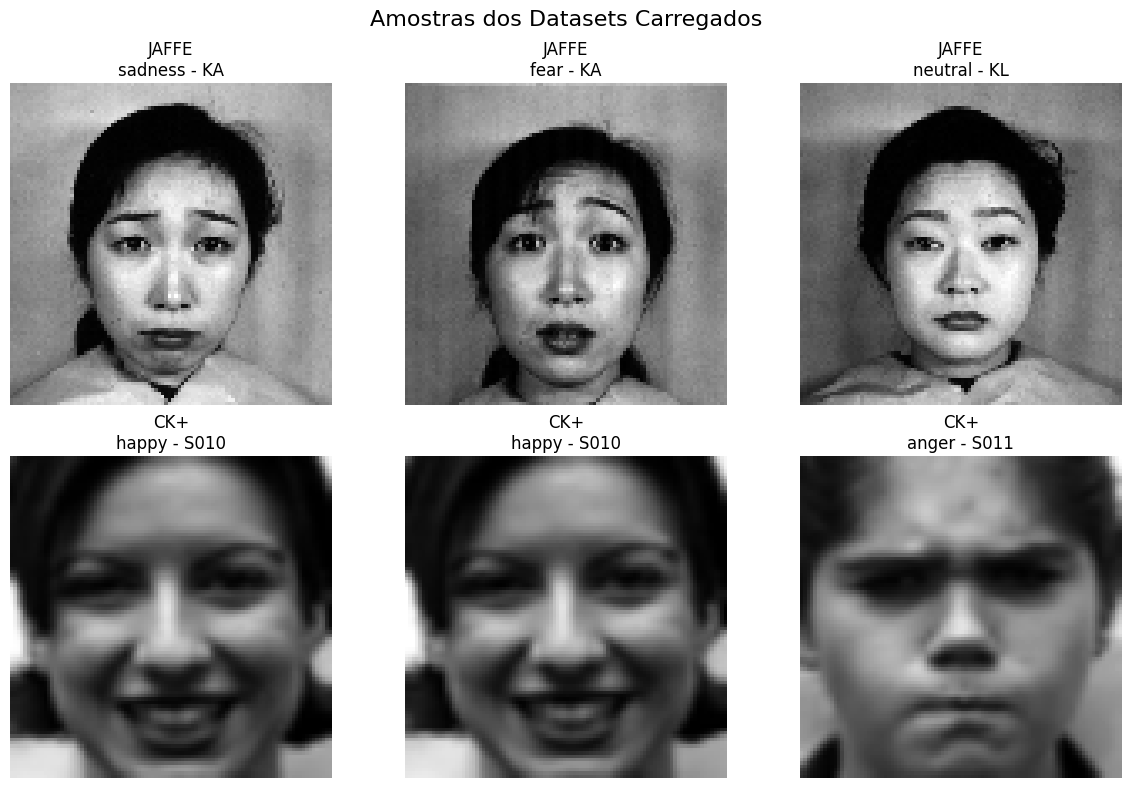


🎯 VALIDAÇÃO FINAL:
----------------------------------------
✅ Datasets encontrados e testados!
🎉 Ambos os datasets (JAFFE e CK+) estão disponíveis!
🚀 Pronto para análise cross-dataset!

📋 PRÓXIMOS PASSOS:
1. Execute o balanceamento híbrido
2. Extraia características LBP
3. Execute análise de drift cross-dataset

🏁 TESTE INICIAL CONCLUÍDO


In [29]:
# ========================================
# TESTE INICIAL - VERIFICAÇÃO DOS DATASETS
# ========================================

import os
import cv2
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

print("🔍 TESTE INICIAL - VERIFICAÇÃO DOS DATASETS")
print("=" * 60)

# ========================================
# 1. VERIFICAR ESTRUTURA DE DIRETÓRIOS
# ========================================

print("\n📁 VERIFICANDO ESTRUTURA DE DIRETÓRIOS:")
print("-" * 40)

# Possíveis caminhos para os datasets
caminhos_possiveis = [
    # Relativos ao notebook atual
    "../data/jaffe",
    "../data/ck+",
    "../../data/jaffe", 
    "../../data/ck+",
    "../../../datasets/jaffe",
    "../../../datasets/ck+",
    # Absolutos (Windows)
    "C:/datasets/jaffe",
    "C:/datasets/ck+",
    # Caminhos do seu notebook
    "..\\data\\jaffe",
    "..\\data\\ck+",
]

caminhos_encontrados = {}

for caminho in caminhos_possiveis:
    caminho_normalizado = os.path.normpath(caminho)
    if os.path.exists(caminho_normalizado):
        dataset_name = "JAFFE" if "jaffe" in caminho.lower() else "CK+"
        caminhos_encontrados[dataset_name] = caminho_normalizado
        print(f"✅ {dataset_name} encontrado: {caminho_normalizado}")
        
        # Listar conteúdo
        try:
            conteudo = os.listdir(caminho_normalizado)
            print(f"   Conteúdo: {conteudo}")
        except Exception as e:
            print(f"   ⚠️ Erro ao listar: {e}")

if not caminhos_encontrados:
    print("❌ Nenhum dataset encontrado!")
    print("\n💡 Verifique se os diretórios existem:")
    print("   - ../data/jaffe/")
    print("   - ../data/ck+/")
    print("\n🔧 Estrutura esperada:")
    print("   notebooks/")
    print("   ├── seu_notebook.ipynb")
    print("   └── data/")
    print("       ├── jaffe/")
    print("       │   ├── anger/")
    print("       │   ├── disgust/")
    print("       │   └── ...")
    print("       └── ck+/")
    print("           ├── anger/")
    print("           ├── disgust/") 
    print("           └── ...")

# ========================================
# 2. FUNÇÃO BÁSICA DE CARREGAMENTO
# ========================================

def carregar_imagens_por_sujeito(dataset_path, image_size=(96, 96), max_por_classe=None):
    """
    Carrega imagens de um diretório organizado por subpastas (classes).
    
    Args:
        dataset_path: Caminho para o dataset
        image_size: Tamanho para redimensionar as imagens
        max_por_classe: Máximo de imagens por classe (None = todas)
    
    Returns:
        Lista de tuplas (imagem, classe, sujeito)
    """
    if not os.path.exists(dataset_path):
        print(f"❌ Diretório não encontrado: {dataset_path}")
        return []
    
    dados = []
    classes = sorted([d for d in os.listdir(dataset_path) 
                     if os.path.isdir(os.path.join(dataset_path, d))])
    
    print(f"\n📂 Carregando {os.path.basename(dataset_path).upper()}:")
    print(f"   Diretório: {dataset_path}")
    print(f"   Classes encontradas: {classes}")
    
    for classe in classes:
        classe_path = os.path.join(dataset_path, classe)
        arquivos = [f for f in os.listdir(classe_path) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if max_por_classe:
            arquivos = arquivos[:max_por_classe]
        
        print(f"   📁 {classe}: {len(arquivos)} imagens")
        
        for i, arquivo in enumerate(arquivos):
            try:
                # Carregar imagem
                img_path = os.path.join(classe_path, arquivo)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                
                if img is None:
                    print(f"      ⚠️ Erro ao carregar: {arquivo}")
                    continue
                
                # Redimensionar
                img = cv2.resize(img, image_size)
                
                # Normalizar para 0-1
                img = img.astype(np.float32) / 255.0
                
                # Extrair ID do sujeito do nome do arquivo
                # JAFFE: nome como "KA.AN1.39.tiff" -> sujeito "KA"
                # CK+: nome como "S005_001_00000011.png" -> sujeito "S005"
                if "jaffe" in dataset_path.lower():
                    sujeito = arquivo.split('.')[0]  # Primeira parte antes do ponto
                else:  # CK+
                    sujeito = arquivo.split('_')[0]  # Primeira parte antes do underscore
                
                dados.append((img, classe, sujeito))
                
            except Exception as e:
                print(f"      ❌ Erro processando {arquivo}: {e}")
                continue
    
    print(f"   ✅ Total carregado: {len(dados)} imagens")
    return dados

# ========================================
# 3. TESTAR CARREGAMENTO SE DATASETS ENCONTRADOS
# ========================================

if caminhos_encontrados:
    print("\n🧪 TESTANDO CARREGAMENTO DOS DATASETS:")
    print("-" * 40)
    
    dados_teste = {}
    
    for dataset_name, caminho in caminhos_encontrados.items():
        print(f"\n📊 Testando {dataset_name}...")
        
        # Carregar apenas algumas imagens para teste
        dados = carregar_imagens_por_sujeito(caminho, max_por_classe=5)
        
        if dados:
            dados_teste[dataset_name] = dados
            
            # Estatísticas básicas
            classes_encontradas = list(set([cls for _, cls, _ in dados]))
            sujeitos_encontrados = list(set([suj for _, _, suj in dados]))
            
            print(f"   ✅ Sucesso!")
            print(f"   📈 Total de imagens: {len(dados)}")
            print(f"   🎭 Classes: {classes_encontradas}")
            print(f"   👥 Sujeitos únicos: {len(sujeitos_encontrados)}")
            print(f"   📐 Formato das imagens: {dados[0][0].shape}")
            
            # Distribuição por classe
            dist_classes = Counter([cls for _, cls, _ in dados])
            print(f"   📊 Distribuição: {dict(dist_classes)}")
            
        else:
            print(f"   ❌ Falha no carregamento!")

# ========================================
# 4. VISUALIZAÇÃO DE AMOSTRA (SE DADOS CARREGADOS)
# ========================================

def visualizar_amostras(dados_teste):
    """Visualiza algumas imagens de cada dataset carregado."""
    
    if not dados_teste:
        print("❌ Nenhum dado carregado para visualizar")
        return
    
    print("\n🖼️ VISUALIZANDO AMOSTRAS:")
    print("-" * 40)
    
    # Determinar layout da figura
    num_datasets = len(dados_teste)
    fig, axes = plt.subplots(num_datasets, 3, figsize=(12, 4*num_datasets))
    
    if num_datasets == 1:
        axes = axes.reshape(1, -1)
    
    for row, (dataset_name, dados) in enumerate(dados_teste.items()):
        # Pegar 3 imagens aleatórias
        indices = np.random.choice(len(dados), min(3, len(dados)), replace=False)
        
        for col, idx in enumerate(indices):
            img, classe, sujeito = dados[idx]
            
            # Plotar
            ax = axes[row, col] if num_datasets > 1 else axes[col]
            ax.imshow(img, cmap='gray')
            ax.set_title(f"{dataset_name}\n{classe} - {sujeito}")
            ax.axis('off')
    
    plt.suptitle('Amostras dos Datasets Carregados', fontsize=16)
    plt.tight_layout()
    plt.show()

# Executar visualização se temos dados
if 'dados_teste' in locals() and dados_teste:
    visualizar_amostras(dados_teste)

# ========================================
# 5. VALIDAÇÃO FINAL
# ========================================

print("\n🎯 VALIDAÇÃO FINAL:")
print("-" * 40)

if caminhos_encontrados:
    print("✅ Datasets encontrados e testados!")
    
    if len(caminhos_encontrados) == 2:
        print("🎉 Ambos os datasets (JAFFE e CK+) estão disponíveis!")
        print("🚀 Pronto para análise cross-dataset!")
        
        # Mostrar próximos passos
        print("\n📋 PRÓXIMOS PASSOS:")
        print("1. Execute o balanceamento híbrido")
        print("2. Extraia características LBP")
        print("3. Execute análise de drift cross-dataset")
        
    else:
        print("⚠️ Apenas um dataset encontrado.")
        print("   Para análise cross-dataset, você precisará de ambos.")
        
else:
    print("❌ Nenhum dataset encontrado!")
    print("📝 AÇÕES NECESSÁRIAS:")
    print("1. Verifique se os diretórios existem")
    print("2. Confirme a estrutura de pastas")
    print("3. Ajuste os caminhos no código")

print("\n" + "=" * 60)
print("🏁 TESTE INICIAL CONCLUÍDO")
print("=" * 60)

In [ ]:
import os
import numpy as np
import cv2
from pathlib import Path
import pickle

def salvar_dados_balanceados_v2(dados_jaffe_balanced, dados_ck_balanced, pasta_destino="../data/processed/"):
    """
    Versão corrigida que funciona com diferentes estruturas de dados
    
    Args:
        dados_jaffe_balanced: Lista de tuplas/listas com dados JAFFE
        dados_ck_balanced: Lista de tuplas/listas com dados CK+
        pasta_destino: Pasta onde salvar os dados processados
    """
    
    # Criar estrutura de pastas
    pasta_destino = Path(pasta_destino)
    pasta_images = pasta_destino / "images"
    pasta_arrays = pasta_destino / "arrays"
    
    # Criar pastas se não existirem
    for pasta in [pasta_destino, pasta_images, pasta_arrays]:
        pasta.mkdir(parents=True, exist_ok=True)
    
    print(f"📁 Salvando dados processados em: {pasta_destino}")
    
    def processar_dataset(dados, nome_dataset):
        """Processa um dataset independente da estrutura"""
        print(f"\n💾 Processando {nome_dataset}...")
        
        if not dados:
            print(f"⚠️ {nome_dataset} está vazio!")
            return [], [], []
        
        # Detectar estrutura dos dados
        amostra = dados[0]
        print(f"🔍 Estrutura detectada: {len(amostra)} elementos")
        
        imagens_lista = []
        labels_lista = []
        metadados_lista = []
        classes_count = {}
        
        pasta_dataset = pasta_images / nome_dataset
        pasta_dataset.mkdir(exist_ok=True)
        
        for idx, item in enumerate(dados):
            try:
                # Extrair dados baseado na estrutura
                if len(item) >= 2:
                    imagem = item[0]
                    label = item[1]
                    
                    # Tentar extrair metadata se existir
                    if len(item) > 2:
                        metadata = item[2]
                        # Se metadata é string, criar dict simples
                        if isinstance(metadata, str):
                            metadata_dict = {'filename': metadata, 'source': nome_dataset}
                        elif isinstance(metadata, dict):
                            metadata_dict = metadata.copy()
                        else:
                            metadata_dict = {'metadata': str(metadata), 'source': nome_dataset}
                    else:
                        metadata_dict = {'source': nome_dataset, 'index': idx}
                    
                    # Validar imagem
                    if not hasattr(imagem, 'shape'):
                        print(f"⚠️ Item {idx}: imagem inválida")
                        continue
                    
                    # Criar pasta da classe
                    pasta_classe = pasta_dataset / str(label)
                    pasta_classe.mkdir(exist_ok=True)
                    
                    # Nome do arquivo
                    nome_arquivo = f"{label}_{idx:04d}.png"
                    
                    # Salvar imagem (normalizar se necessário)
                    if imagem.max() <= 1.0:
                        imagem_salvar = (imagem * 255).astype(np.uint8)
                    else:
                        imagem_salvar = imagem.astype(np.uint8)
                    
                    # Garantir que é 2D (grayscale)
                    if len(imagem_salvar.shape) > 2:
                        imagem_salvar = imagem_salvar[:,:,0]
                    
                    caminho_arquivo = pasta_classe / nome_arquivo
                    cv2.imwrite(str(caminho_arquivo), imagem_salvar)
                    
                    # Adicionar às listas
                    imagens_lista.append(imagem)
                    labels_lista.append(label)
                    metadados_lista.append(metadata_dict)
                    
                    # Contar classes
                    classes_count[str(label)] = classes_count.get(str(label), 0) + 1
                    
                except Exception as e:
                    print(f"⚠️ Erro processando item {idx}: {e}")
                    continue
        
        print(f"✅ {nome_dataset}: {len(imagens_lista)} imagens salvas")
        print(f"📊 Distribuição: {classes_count}")
        
        return imagens_lista, labels_lista, metadados_lista, classes_count
    
    # Processar ambos os datasets
    datasets_info = {}
    
    if dados_jaffe_balanced:
        jaffe_imgs, jaffe_labels, jaffe_meta, jaffe_stats = processar_dataset(
            dados_jaffe_balanced, "jaffe_balanced"
        )
        datasets_info['jaffe_balanced'] = jaffe_stats
        
        # Salvar arrays JAFFE
        if jaffe_imgs:
            np.save(pasta_arrays / "jaffe_balanced_images.npy", np.array(jaffe_imgs))
            np.save(pasta_arrays / "jaffe_balanced_labels.npy", np.array(jaffe_labels))
            with open(pasta_arrays / "jaffe_balanced_metadata.pkl", 'wb') as f:
                pickle.dump(jaffe_meta, f)
            print(f"✅ Arrays JAFFE salvos: {np.array(jaffe_imgs).shape}")
    
    if dados_ck_balanced:
        ck_imgs, ck_labels, ck_meta, ck_stats = processar_dataset(
            dados_ck_balanced, "ck_balanced"
        )
        datasets_info['ck_balanced'] = ck_stats
        
        # Salvar arrays CK+
        if ck_imgs:
            np.save(pasta_arrays / "ck_balanced_images.npy", np.array(ck_imgs))
            np.save(pasta_arrays / "ck_balanced_labels.npy", np.array(ck_labels))
            with open(pasta_arrays / "ck_balanced_metadata.pkl", 'wb') as f:
                pickle.dump(ck_meta, f)
            print(f"✅ Arrays CK+ salvos: {np.array(ck_imgs).shape}")
    
    # Salvar estatísticas
    stats_file = pasta_destino / "estatisticas_balanceamento.txt"
    with open(stats_file, 'w', encoding='utf-8') as f:
        f.write("=== ESTATÍSTICAS DO BALANCEAMENTO ===\n\n")
        for dataset, stats in datasets_info.items():
            f.write(f"{dataset.upper()}:\n")
            total = sum(stats.values())
            f.write(f"Total: {total} imagens\n")
            for classe, count in sorted(stats.items()):
                porcentagem = (count/total)*100 if total > 0 else 0
                f.write(f"  {classe}: {count} ({porcentagem:.1f}%)\n")
            f.write("\n")
    
    # Criar script de carregamento
    script_carregamento = pasta_destino / "carregar_dados.py"
    with open(script_carregamento, 'w', encoding='utf-8') as f:
        f.write('''
import numpy as np
import pickle
from pathlib import Path

def carregar_dados_balanceados(pasta_arrays="../data/processed/arrays/"):
    """
    Carrega os dados balanceados salvos
    
    Returns:
        dados_jaffe_balanced, dados_ck_balanced
    """
    pasta = Path(pasta_arrays)
    dados_jaffe = None
    dados_ck = None
    
    try:
        # Tentar carregar JAFFE
        if (pasta / "jaffe_balanced_images.npy").exists():
            jaffe_imgs = np.load(pasta / "jaffe_balanced_images.npy")
            jaffe_labels = np.load(pasta / "jaffe_balanced_labels.npy")
            with open(pasta / "jaffe_balanced_metadata.pkl", 'rb') as f:
                jaffe_metadata = pickle.load(f)
            dados_jaffe = list(zip(jaffe_imgs, jaffe_labels, jaffe_metadata))
            print(f"✅ JAFFE carregado: {len(dados_jaffe)} amostras")
        else:
            print("⚠️ Dados JAFFE não encontrados")
    except Exception as e:
        print(f"❌ Erro carregando JAFFE: {e}")
    
    try:
        # Tentar carregar CK+
        if (pasta / "ck_balanced_images.npy").exists():
            ck_imgs = np.load(pasta / "ck_balanced_images.npy") 
            ck_labels = np.load(pasta / "ck_balanced_labels.npy")
            with open(pasta / "ck_balanced_metadata.pkl", 'rb') as f:
                ck_metadata = pickle.load(f)
            dados_ck = list(zip(ck_imgs, ck_labels, ck_metadata))
            print(f"✅ CK+ carregado: {len(dados_ck)} amostras")
        else:
            print("⚠️ Dados CK+ não encontrados")
    except Exception as e:
        print(f"❌ Erro carregando CK+: {e}")
    
    return dados_jaffe, dados_ck

# Exemplo de uso:
# dados_jaffe_balanced, dados_ck_balanced = carregar_dados_balanceados()
''')
    
    print(f"""
🎉 DADOS SALVOS COM SUCESSO!

📁 Estrutura criada:
{pasta_destino}/
├── images/                     # Imagens organizadas por classe
│   ├── jaffe_balanced/
│   └── ck_balanced/
├── arrays/                     # Arrays numpy (carregamento rápido)
│   ├── *_images.npy
│   ├── *_labels.npy
│   └── *_metadata.pkl
├── estatisticas_balanceamento.txt
└── carregar_dados.py

📋 PRÓXIMOS PASSOS:
1. Para continuar: use as variáveis em memória
2. Para recarregar: execute carregar_dados.py
3. Para Passo 2 (LBP): dados prontos!
""")
    
    return datasets_info

# EXECUTAR O SALVAMENTO CORRIGIDO
if 'dados_jaffe_balanced' in locals() and 'dados_ck_balanced' in locals():
    print("🚀 Iniciando salvamento dos dados balanceados...")
    stats = salvar_dados_balanceados_v2(dados_jaffe_balanced, dados_ck_balanced)
    print("✅ Salvamento concluído!")
else:
    print("❌ Variáveis dados_jaffe_balanced e dados_ck_balanced não encontradas!")
    print("Execute primeiro o Passo 1 (balanceamento)")

SyntaxError: invalid syntax (136682058.py, line 95)

In [38]:


def salvar_dados_balanceados(dados_jaffe_balanced, dados_ck_balanced, pasta_destino="../data/processed/"):
    """
    Salva os dados balanceados tanto como imagens organizadas quanto como arquivos numpy
    
    Args:
        dados_jaffe_balanced: Lista de tuplas (imagem_array, label, metadata)
        dados_ck_balanced: Lista de tuplas (imagem_array, label, metadata)  
        pasta_destino: Pasta onde salvar os dados processados
    """
    
    # Criar estrutura de pastas
    pasta_destino = Path(pasta_destino)
    pasta_images = pasta_destino / "images"
    pasta_arrays = pasta_destino / "arrays"
    
    # Criar pastas se não existirem
    for pasta in [pasta_destino, pasta_images, pasta_arrays]:
        pasta.mkdir(parents=True, exist_ok=True)
    
    print(f"📁 Salvando dados processados em: {pasta_destino}")
    
    # 1. SALVAR COMO IMAGENS ORGANIZADAS POR CLASSE
    print("💾 Salvando imagens organizadas...")
    
    datasets = {
        'jaffe_balanced': dados_jaffe_balanced,
        'ck_balanced': dados_ck_balanced
    }
    
    estatisticas = {}
    
    for dataset_nome, dados in datasets.items():
        pasta_dataset = pasta_images / dataset_nome
        pasta_dataset.mkdir(exist_ok=True)
        
        # Organizar por classe
        classes_count = {}
        
        for idx, (imagem, label, metadata) in enumerate(dados):
            # Criar pasta da classe
            pasta_classe = pasta_dataset / label
            pasta_classe.mkdir(exist_ok=True)
            
            # Nome do arquivo único
            if 'original_filename' in metadata:
                nome_base = metadata['original_filename'].split('.')[0]
            else:
                nome_base = f"{label}_{idx}"
            
            # Adicionar sufixo se for sintética
            if metadata.get('sintética', False):
                nome_arquivo = f"{nome_base}_synth_{idx:04d}.png"
            else:
                nome_arquivo = f"{nome_base}_orig_{idx:04d}.png"
            
            # Salvar imagem (converter de [0,1] para [0,255])
            if imagem.max() <= 1.0:
                imagem_salvar = (imagem * 255).astype(np.uint8)
            else:
                imagem_salvar = imagem.astype(np.uint8)
            
            caminho_arquivo = pasta_classe / nome_arquivo
            cv2.imwrite(str(caminho_arquivo), imagem_salvar)
            
            # Contar classes
            classes_count[label] = classes_count.get(label, 0) + 1
        
        estatisticas[dataset_nome] = classes_count
        print(f"✅ {dataset_nome}: {len(dados)} imagens salvas")
    
    # 2. SALVAR COMO ARRAYS NUMPY (MAIS EFICIENTE PARA CARREGAR)
    print("💾 Salvando arrays numpy...")
    
    # Separar dados por dataset
    for dataset_nome, dados in datasets.items():
        if dados:  # Se não estiver vazio
            # Separar imagens, labels e metadados
            imagens = np.array([item[0] for item in dados])
            labels = np.array([item[1] for item in dados])
            metadados = [item[2] for item in dados]
            
            # Salvar arrays
            np.save(pasta_arrays / f"{dataset_nome}_images.npy", imagens)
            np.save(pasta_arrays / f"{dataset_nome}_labels.npy", labels)
            
            # Salvar metadados com pickle
            with open(pasta_arrays / f"{dataset_nome}_metadata.pkl", 'wb') as f:
                pickle.dump(metadados, f)
            
            print(f"✅ {dataset_nome} arrays salvos: {imagens.shape}")
    
    # 3. SALVAR ESTATÍSTICAS
    stats_file = pasta_destino / "estatisticas_balanceamento.txt"
    with open(stats_file, 'w') as f:
        f.write("=== ESTATÍSTICAS DO BALANCEAMENTO ===\n\n")
        for dataset, stats in estatisticas.items():
            f.write(f"{dataset.upper()}:\n")
            total = sum(stats.values())
            f.write(f"Total: {total} imagens\n")
            for classe, count in sorted(stats.items()):
                porcentagem = (count/total)*100
                f.write(f"  {classe}: {count} ({porcentagem:.1f}%)\n")
            f.write("\n")
    
    # 4. CRIAR SCRIPT DE CARREGAMENTO
    script_carregamento = pasta_destino / "carregar_dados.py"
    with open(script_carregamento, 'w') as f:
        f.write('''
import numpy as np
import pickle
from pathlib import Path

def carregar_dados_balanceados(pasta_arrays="../data/processed/arrays/"):
    """
    Carrega os dados balanceados salvos
    
    Returns:
        dados_jaffe_balanced, dados_ck_balanced
    """
    pasta = Path(pasta_arrays)
    
    # Carregar JAFFE
    jaffe_imgs = np.load(pasta / "jaffe_balanced_images.npy")
    jaffe_labels = np.load(pasta / "jaffe_balanced_labels.npy")
    with open(pasta / "jaffe_balanced_metadata.pkl", 'rb') as f:
        jaffe_metadata = pickle.load(f)
    
    # Carregar CK+
    ck_imgs = np.load(pasta / "ck_balanced_images.npy") 
    ck_labels = np.load(pasta / "ck_balanced_labels.npy")
    with open(pasta / "ck_balanced_metadata.pkl", 'rb') as f:
        ck_metadata = pickle.load(f)
    
    # Recriar formato original
    dados_jaffe = list(zip(jaffe_imgs, jaffe_labels, jaffe_metadata))
    dados_ck = list(zip(ck_imgs, ck_labels, ck_metadata))
    
    print(f"✅ Dados carregados:")
    print(f"  JAFFE: {len(dados_jaffe)} amostras")
    print(f"  CK+: {len(dados_ck)} amostras")
    
    return dados_jaffe, dados_ck

# Exemplo de uso:
# dados_jaffe_balanced, dados_ck_balanced = carregar_dados_balanceados()
''')
    
    print(f"""
🎉 DADOS SALVOS COM SUCESSO!

📁 Estrutura criada:
{pasta_destino}/
├── images/                     # Imagens organizadas por classe
│   ├── jaffe_balanced/
│   │   ├── anger/
│   │   ├── disgust/
│   │   └── ...
│   └── ck_balanced/
│       ├── anger/
│       └── ...
├── arrays/                     # Arrays numpy (carregamento rápido)
│   ├── jaffe_balanced_images.npy
│   ├── jaffe_balanced_labels.npy
│   ├── jaffe_balanced_metadata.pkl
│   ├── ck_balanced_images.npy
│   ├── ck_balanced_labels.npy
│   └── ck_balanced_metadata.pkl
├── estatisticas_balanceamento.txt
└── carregar_dados.py           # Script para recarregar

📋 PRÓXIMOS PASSOS:
1. Para continuar na mesma sessão: use as variáveis em memória
2. Para nova sessão: execute carregar_dados.py
3. Para Passo 2 (LBP): os dados estão prontos!
""")
    
    return estatisticas

# EXECUTAR O SALVAMENTO
if 'dados_jaffe_balanced' in locals() and 'dados_ck_balanced' in locals():
    stats = salvar_dados_balanceados(dados_jaffe_balanced, dados_ck_balanced)
else:
    print("❌ Variáveis dados_jaffe_balanced e dados_ck_balanced não encontradas!")
    print("Execute primeiro o Passo 1 (balanceamento)")

📁 Salvando dados processados em: ..\data\processed
💾 Salvando imagens organizadas...


AttributeError: 'str' object has no attribute 'get'

In [32]:
CONFIG = {
    'random_state': 42,
    'target_size': (128, 128),
    'usar_preprocessamento': True,
    'classes_alvo': ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sadness', 'surprise']
}

np.random.seed(CONFIG['random_state'])
random.seed(CONFIG['random_state'])

print(f"⚙️ Configurações: {CONFIG}")

# ========================================
# FUNÇÕES AUXILIARES
# ========================================

def shannon_entropy(image):
    """Calcula entropia de Shannon para uma imagem."""
    if image.dtype != np.uint8:
        if image.max() <= 1.0:
            image = (image * 255).astype(np.uint8)
        else:
            image = image.astype(np.uint8)
    
    histogram, _ = np.histogram(image, bins=256, range=(0, 256), density=True)
    histogram = histogram[histogram > 0]  # Remove zeros
    return entropy(histogram, base=2)

def redimensionar_preservando_aspecto(imagem, target_size=(128, 128)):
    """Redimensiona imagem preservando proporções com padding."""
    h, w = imagem.shape
    target_w, target_h = target_size
    
    # Calcular nova dimensão mantendo aspecto
    ratio = min(target_w / w, target_h / h)
    new_w = int(w * ratio)
    new_h = int(h * ratio)
    
    # Redimensionar
    resized = cv2.resize(imagem, (new_w, new_h), interpolation=cv2.INTER_LANCZOS4)
    
    # Criar canvas com padding
    canvas = np.zeros((target_h, target_w), dtype=imagem.dtype)
    
    # Centralizar
    start_y = (target_h - new_h) // 2
    start_x = (target_w - new_w) // 2
    canvas[start_y:start_y+new_h, start_x:start_x+new_w] = resized
    
    return canvas

def preprocessar_para_otimizar_resolucao(imagem):
    """Aplica pré-processamento para otimizar resolução reduzida."""
    # Converter para uint8 se necessário
    if imagem.dtype != np.uint8:
        if imagem.max() <= 1.0:
            img_uint8 = (imagem * 255).astype(np.uint8)
        else:
            img_uint8 = imagem.astype(np.uint8)
    else:
        img_uint8 = imagem.copy()
    
    # 1. CLAHE para melhorar contraste local
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_eq = clahe.apply(img_uint8)
    
    # 2. Filtro bilateral para reduzir ruído preservando bordas
    img_filtered = cv2.bilateralFilter(img_eq, 9, 75, 75)
    
    # 3. Sharpening sutil
    kernel_sharpen = np.array([[-0.5, -0.5, -0.5], 
                              [-0.5,  5.0, -0.5], 
                              [-0.5, -0.5, -0.5]])
    img_sharp = cv2.filter2D(img_filtered, -1, kernel_sharpen)
    
    # Normalizar para 0-1
    return np.clip(img_sharp / 255.0, 0, 1)

# ========================================
# FUNÇÃO DE CARREGAMENTO
# ========================================

def carregar_dataset_completo(dataset_path, dataset_name):
    """Carrega dataset completo com todas as imagens."""
    
    print(f"\n📂 Carregando {dataset_name} completo...")
    print(f"   Diretório: {dataset_path}")
    
    if not os.path.exists(dataset_path):
        print(f"   ❌ Diretório não encontrado!")
        return []
    
    dados = []
    classes = sorted([d for d in os.listdir(dataset_path) 
                     if os.path.isdir(os.path.join(dataset_path, d))])
    
    total_por_classe = {}
    
    for classe in classes:
        classe_path = os.path.join(dataset_path, classe)
        arquivos = [f for f in os.listdir(classe_path) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff'))]
        
        print(f"   📁 {classe}: {len(arquivos)} imagens", end="")
        
        classe_dados = []
        for arquivo in arquivos:
            try:
                img_path = os.path.join(classe_path, arquivo)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                
                if img is None:
                    continue
                
                # Extrair sujeito
                if "jaffe" in dataset_name.lower():
                    sujeito = arquivo.split('.')[0]  # KA, KB, etc.
                else:  # CK+
                    sujeito = arquivo.split('_')[0]  # S005, S010, etc.
                
                classe_dados.append((img, classe, sujeito))
                
            except Exception as e:
                continue
        
        dados.extend(classe_dados)
        total_por_classe[classe] = len(classe_dados)
        print(f" ✅")
    
    print(f"   📊 Total {dataset_name}: {len(dados)} imagens")
    print(f"   🎭 Distribuição: {total_por_classe}")
    
    return dados

# ========================================
# CLASSE BALANCEADOR HÍBRIDO
# ========================================

class BalanceadorHibrido:
    """Balanceador híbrido cross-dataset com análise inteligente."""
    
    def __init__(self, config=None):
        self.config = config or CONFIG
        self.target_size = self.config['target_size']
        self.usar_preprocessamento = self.config['usar_preprocessamento']
        
        print(f"\n🔧 BalanceadorHibrido inicializado:")
        print(f"   • Resolução alvo: {self.target_size}")
        print(f"   • Pré-processamento: {'Ativado' if self.usar_preprocessamento else 'Desativado'}")
    
    def processar_imagem(self, imagem):
        """Processa imagem com redimensionamento e otimização."""
        # Redimensionar preservando aspecto
        img_resized = redimensionar_preservando_aspecto(imagem, self.target_size)
        
        # Aplicar pré-processamento se ativado
        if self.usar_preprocessamento:
            img_processed = preprocessar_para_otimizar_resolucao(img_resized)
        else:
            # Apenas normalizar
            if img_resized.max() > 1.0:
                img_processed = img_resized.astype(np.float32) / 255.0
            else:
                img_processed = img_resized.astype(np.float32)
        
        return img_processed
    
    def executar_balanceamento(self, dados_jaffe, dados_ck, classes_alvo=None):
        """Executa balanceamento híbrido cross-dataset."""
        
        print(f"\n🧠 EXECUTANDO BALANCEAMENTO HÍBRIDO")
        print("=" * 50)
        
        if classes_alvo is None:
            classes_alvo = self.config['classes_alvo']
        
        # Processar imagens de entrada
        print(f"🔄 Processando imagens para resolução {self.target_size}...")
        
        dados_jaffe_proc = []
        for img, cls, suj in dados_jaffe:
            if cls in classes_alvo:
                img_proc = self.processar_imagem(img)
                dados_jaffe_proc.append((img_proc, cls, suj))
        
        dados_ck_proc = []
        for img, cls, suj in dados_ck:
            if cls in classes_alvo:
                img_proc = self.processar_imagem(img)
                dados_ck_proc.append((img_proc, cls, suj))
        
        print(f"✅ JAFFE processado: {len(dados_jaffe_proc)} imagens")
        print(f"✅ CK+ processado: {len(dados_ck_proc)} imagens")
        
        # Agrupar por classe
        jaffe_por_classe = self._agrupar_por_classe(dados_jaffe_proc)
        ck_por_classe = self._agrupar_por_classe(dados_ck_proc)
        
        # Executar balanceamento por classe
        print(f"\n📊 PLANO DE BALANCEAMENTO:")
        print("Classe       JAFFE    CK+     Target   Sintéticas_J  Sintéticas_C")
        print("-" * 65)
        
        dados_jaffe_balanced = []
        dados_ck_balanced = []
        stats_detalhados = {}
        
        for classe in classes_alvo:
            jaffe_classe = jaffe_por_classe.get(classe, [])
            ck_classe = ck_por_classe.get(classe, [])
            
            if not jaffe_classe or not ck_classe:
                print(f"{classe:12} {len(jaffe_classe):6d}   {len(ck_classe):6d}   SKIP")
                continue
            
            # Target: igualar ao maior (estratégia de expansão)
            target = max(len(jaffe_classe), len(ck_classe))
            sinteticas_jaffe = max(0, target - len(jaffe_classe))
            sinteticas_ck = max(0, target - len(ck_classe))
            
            print(f"{classe:12} {len(jaffe_classe):6d}   {len(ck_classe):6d}   {target:6d}   {sinteticas_jaffe:11d}   {sinteticas_ck:11d}")
            
            # Processar JAFFE (análise híbrida)
            jaffe_final = self._balancear_classe(
                jaffe_classe, ck_classe, target, "JAFFE", classe
            )
            
            # Processar CK+ (augmentation simples se necessário)
            ck_final = self._balancear_classe(
                ck_classe, jaffe_classe, target, "CK+", classe
            )
            
            dados_jaffe_balanced.extend(jaffe_final)
            dados_ck_balanced.extend(ck_final)
            
            stats_detalhados[classe] = {
                'jaffe_original': len(jaffe_classe),
                'ck_original': len(ck_classe),
                'target': target,
                'jaffe_sinteticas': sinteticas_jaffe,
                'ck_sinteticas': sinteticas_ck,
                'jaffe_final': len(jaffe_final),
                'ck_final': len(ck_final)
            }
        
        print("-" * 65)
        print(f"{'TOTAL':12} {len(dados_jaffe_balanced):6d}   {len(dados_ck_balanced):6d}")
        
        # Gerar relatório
        self._gerar_relatorio_final(stats_detalhados)
        
        return dados_jaffe_balanced, dados_ck_balanced, stats_detalhados
    
    def _agrupar_por_classe(self, dados):
        """Agrupa dados por classe."""
        grupos = defaultdict(list)
        for img, cls, suj in dados:
            grupos[cls].append((img, cls, suj))
        return dict(grupos)
    
    def _balancear_classe(self, dados_classe, dados_ref, target, dataset_name, classe):
        """Balanceia uma classe específica."""
        
        dados_final = dados_classe.copy()
        sinteticas_needed = max(0, target - len(dados_classe))
        
        if sinteticas_needed == 0:
            return dados_final
        
        if dataset_name == "JAFFE" and sinteticas_needed > 0:
            # Análise híbrida para JAFFE
            print(f"\\n🔍 Análise híbrida: {classe} (JAFFE)")
            
            # Avaliar qualidade das imagens
            scores_qualidade = self._avaliar_qualidade(dados_classe)
            
            # Avaliar unicidade vs CK+
            scores_unicidade = self._calcular_unicidade(dados_classe, dados_ref)
            
            # Distribuir quotas inteligentemente
            quotas = self._distribuir_quotas(
                dados_classe, scores_qualidade, scores_unicidade, sinteticas_needed
            )
            
            # Gerar sintéticas com diversidade máxima
            sinteticas = self._gerar_sinteticas_inteligentes(dados_classe, quotas, classe)
            
        else:
            # CK+: augmentation simples
            sinteticas = []
            for i in range(sinteticas_needed):
                img_base, cls, suj_base = random.choice(dados_classe)
                tecnica = random.choice(['horizontal_flip', 'brightness_up', 'rotation_left'])
                img_sint = self._aplicar_transformacao(img_base, tecnica)
                suj_sint = f"{suj_base}_{dataset_name.lower()}_aug_{i:03d}"
                sinteticas.append((img_sint, cls, suj_sint))
        
        dados_final.extend(sinteticas)
        return dados_final
    
    def _avaliar_qualidade(self, dados_classe):
        """Avalia qualidade das imagens."""
        scores = {}
        
        for img, cls, suj in dados_classe:
            # Converter para uint8
            if img.max() <= 1.0:
                img_uint8 = (img * 255).astype(np.uint8)
            else:
                img_uint8 = img.astype(np.uint8)
            
            # Métricas de qualidade
            nitidez = cv2.Laplacian(img_uint8, cv2.CV_64F).var()
            contraste = np.std(img_uint8)
            entropia = shannon_entropy(img_uint8)
            
            # Score normalizado
            score = (min(nitidez/500, 10) + min(contraste/50, 10) + min(entropia/8, 10)) / 3
            scores[suj] = min(score, 10.0)
        
        return scores
    
    def _calcular_unicidade(self, dados_classe, dados_ref):
        """Calcula unicidade vs dataset de referência."""
        scores = {}
        
        # Features LBP simples
        features_classe = []
        sujeitos = []
        
        for img, cls, suj in dados_classe:
            img_uint8 = (img * 255).astype(np.uint8) if img.max() <= 1.0 else img.astype(np.uint8)
            lbp = local_binary_pattern(img_uint8, 8, 1, method='uniform')
            hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0, 10), density=True)
            features_classe.append(hist)
            sujeitos.append(suj)
        
        features_ref = []
        for img, cls, suj in dados_ref:
            img_uint8 = (img * 255).astype(np.uint8) if img.max() <= 1.0 else img.astype(np.uint8)
            lbp = local_binary_pattern(img_uint8, 8, 1, method='uniform')
            hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0, 10), density=True)
            features_ref.append(hist)
        
        if features_ref:
            features_classe = np.array(features_classe)
            features_ref = np.array(features_ref)
            
            for i, suj in enumerate(sujeitos):
                similaridades = cosine_similarity([features_classe[i]], features_ref)[0]
                max_sim = np.max(similaridades)
                scores[suj] = (1 - max_sim) * 10
        else:
            for suj in sujeitos:
                scores[suj] = 5.0  # Score neutro
        
        return scores
    
    def _distribuir_quotas(self, dados_classe, scores_qual, scores_unic, total_needed):
        """Distribui quotas baseado em qualidade e unicidade."""
        
        # Combinar scores (60% qualidade, 40% unicidade)
        scores_finais = {}
        for suj in scores_qual.keys():
            score_final = (scores_qual[suj] * 0.6) + (scores_unic[suj] * 0.4)
            scores_finais[suj] = score_final
        
        # Ordenar por score
        sujeitos_ordenados = sorted(scores_finais.keys(), 
                                  key=lambda x: scores_finais[x], reverse=True)
        
        # Distribuir quotas
        n_imagens = len(dados_classe)
        quota_base = total_needed // n_imagens
        quota_extra = total_needed % n_imagens
        
        quotas = {}
        for i, suj in enumerate(sujeitos_ordenados):
            quota = quota_base
            if i < quota_extra:  # Distribuir extras para os melhores
                quota += 1
            quotas[suj] = quota
        
        return quotas
    
    def _gerar_sinteticas_inteligentes(self, dados_classe, quotas, classe):
        """Gera sintéticas com máxima diversidade."""
        
        sinteticas = []
        mapa_sujeito = {suj: (img, cls, suj) for img, cls, suj in dados_classe}
        
        for suj, quota in quotas.items():
            if quota <= 0:
                continue
            
            img_base, cls, _ = mapa_sujeito[suj]
            
            # Gerar transformações diversas
            tecnicas = ['horizontal_flip', 'rotation_left', 'rotation_right', 
                       'brightness_up', 'brightness_down', 'contrast_up', 'noise']
            
            for i in range(quota):
                tecnica = tecnicas[i % len(tecnicas)]  # Circular
                img_sint = self._aplicar_transformacao(img_base, tecnica)
                suj_sint = f"{suj}_hyb_{i:03d}"
                sinteticas.append((img_sint, cls, suj_sint))
        
        return sinteticas
    
    def _aplicar_transformacao(self, imagem, tecnica):
        """Aplica transformação específica."""
        img = imagem.astype(np.float32) if imagem.dtype != np.float32 else imagem
        h, w = img.shape
        center = (w // 2, h // 2)
        
        if tecnica == 'horizontal_flip':
            return cv2.flip(img, 1)
        elif tecnica == 'rotation_left':
            angle = np.random.uniform(-8, -3)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
        elif tecnica == 'rotation_right':
            angle = np.random.uniform(3, 8)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
        elif tecnica == 'brightness_up':
            return np.clip(img * np.random.uniform(1.1, 1.3), 0, 1)
        elif tecnica == 'brightness_down':
            return np.clip(img * np.random.uniform(0.7, 0.9), 0, 1)
        elif tecnica == 'contrast_up':
            alpha = np.random.uniform(1.1, 1.3)
            return np.clip(alpha * (img - 0.5) + 0.5, 0, 1)
        elif tecnica == 'noise':
            noise = np.random.normal(0, 0.02, img.shape)
            return np.clip(img + noise, 0, 1)
        else:
            return img
    
    def _gerar_relatorio_final(self, stats):
        """Gera relatório final do balanceamento."""
        
        print(f"\n📊 RELATÓRIO FINAL - BALANCEAMENTO HÍBRIDO")
        print("=" * 60)
        
        total_jaffe_orig = sum([s['jaffe_original'] for s in stats.values()])
        total_ck_orig = sum([s['ck_original'] for s in stats.values()])
        total_jaffe_final = sum([s['jaffe_final'] for s in stats.values()])
        total_ck_final = sum([s['ck_final'] for s in stats.values()])
        total_sinteticas = sum([s['jaffe_sinteticas'] + s['ck_sinteticas'] for s in stats.values()])
        
        print(f"\n📈 RESUMO GERAL:")
        print(f"   • JAFFE: {total_jaffe_orig} → {total_jaffe_final} amostras")
        print(f"   • CK+: {total_ck_orig} → {total_ck_final} amostras")
        print(f"   • Total sintéticas: {total_sinteticas}")
        print(f"   • Resolução final: {self.target_size}")
        
        # Verificar balanceamento
        if total_jaffe_final + total_ck_final > 0:
            ratio = (total_ck_final / (total_jaffe_final + total_ck_final)) * 100
            desvio = abs(50 - ratio)
            print(f"\n🎯 EFICIÊNCIA:")
            print(f"   • Ratio: {100-ratio:.1f}% JAFFE / {ratio:.1f}% CK+")
            print(f"   • Desvio do 50/50: {desvio:.1f} pontos percentuais")
            
            if desvio < 5:
                print("   🎉 EXCELENTE: Balanceamento quase perfeito!")
            elif desvio < 10:
                print("   ✅ BOM: Balanceamento adequado")
            else:
                print("   ⚠️ ACEITÁVEL: Pequeno desvio do ideal")

# ========================================
# DETECÇÃO AUTOMÁTICA DOS CAMINHOS
# ========================================

def encontrar_datasets():
    """Encontra automaticamente os caminhos dos datasets."""
    
    print("\n🔍 DETECTANDO DATASETS AUTOMATICAMENTE...")
    
    # Possíveis caminhos
    caminhos_teste = [
        ("../data/jaffe", "../data/ck+"),
        ("../../data/jaffe", "../../data/ck+"),
        ("../../../datasets/jaffe", "../../../datasets/ck+"),
        ("data/jaffe", "data/ck+"),
    ]
    
    for caminho_jaffe, caminho_ck in caminhos_teste:
        if os.path.exists(caminho_jaffe) and os.path.exists(caminho_ck):
            print(f"✅ Datasets encontrados:")
            print(f"   • JAFFE: {caminho_jaffe}")
            print(f"   • CK+: {caminho_ck}")
            return {'JAFFE': caminho_jaffe, 'CK+': caminho_ck}
    
    print("❌ Datasets não encontrados automaticamente")
    return {}

# ========================================
# EXECUÇÃO PRINCIPAL
# ========================================

# Detectar datasets
caminhos_encontrados = encontrar_datasets()

if caminhos_encontrados:
    print(f"\n🎯 INICIANDO BALANCEAMENTO HÍBRIDO")
    print(f"⏰ Timestamp: {datetime.now().strftime('%H:%M:%S')}")
    
    # Carregar datasets completos
    print("\n📂 CARREGANDO DATASETS...")
    
    dados_jaffe_completo = carregar_dataset_completo(
        caminhos_encontrados['JAFFE'], 'JAFFE'
    )
    
    dados_ck_completo = carregar_dataset_completo(
        caminhos_encontrados['CK+'], 'CK+'
    )
    
    # Verificar se temos dados suficientes
    if dados_jaffe_completo and dados_ck_completo:
        print(f"\n✅ Dados carregados com sucesso!")
        print(f"   • JAFFE: {len(dados_jaffe_completo)} imagens")
        print(f"   • CK+: {len(dados_ck_completo)} imagens")
        
        # Executar balanceamento
        print(f"\n🔄 INICIANDO BALANCEAMENTO...")
        balanceador = BalanceadorHibrido(CONFIG)
        
        dados_jaffe_balanced, dados_ck_balanced, stats_balanceamento = balanceador.executar_balanceamento(
            dados_jaffe_completo, dados_ck_completo
        )
        
        print(f"\n🎉 BALANCEAMENTO CONCLUÍDO!")
        print(f"   • JAFFE balanceado: {len(dados_jaffe_balanced)} amostras")
        print(f"   • CK+ balanceado: {len(dados_ck_balanced)} amostras")
        print(f"   • Resolução: {CONFIG['target_size']}")
        print(f"   • Pré-processamento: {'Aplicado' if CONFIG['usar_preprocessamento'] else 'Não aplicado'}")
        
        # Disponibilizar variáveis para próximos passos
        print(f"\n📋 VARIÁVEIS DISPONÍVEIS:")
        print(f"   • dados_jaffe_balanced: {len(dados_jaffe_balanced)} amostras")
        print(f"   • dados_ck_balanced: {len(dados_ck_balanced)} amostras")
        print(f"   • stats_balanceamento: estatísticas detalhadas")
        
        # Verificação rápida da qualidade
        print(f"\n🔍 VERIFICAÇÃO RÁPIDA:")
        jaffe_classes = Counter([cls for _, cls, _ in dados_jaffe_balanced])
        ck_classes = Counter([cls for _, cls, _ in dados_ck_balanced])
        print(f"   • JAFFE por classe: {dict(jaffe_classes)}")
        print(f"   • CK+ por classe: {dict(ck_classes)}")
        
    else:
        print(f"\n❌ ERRO: Datasets não carregados corretamente")
        print(f"   • JAFFE: {len(dados_jaffe_completo)} imagens")
        print(f"   • CK+: {len(dados_ck_completo)} imagens")
        
else:
    print(f"\n❌ ERRO: Datasets não encontrados")
    print(f"   Execute primeiro o teste de carregamento ou ajuste os caminhos")

print(f"\n🏁 PASSO 1 CONCLUÍDO")
print("=" * 70)

⚙️ Configurações: {'random_state': 42, 'target_size': (128, 128), 'usar_preprocessamento': True, 'classes_alvo': ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sadness', 'surprise']}

🔍 DETECTANDO DATASETS AUTOMATICAMENTE...
✅ Datasets encontrados:
   • JAFFE: ../data/jaffe
   • CK+: ../data/ck+

🎯 INICIANDO BALANCEAMENTO HÍBRIDO
⏰ Timestamp: 21:14:12

📂 CARREGANDO DATASETS...

📂 Carregando JAFFE completo...
   Diretório: ../data/jaffe
   📁 anger: 30 imagens ✅
   📁 disgust: 29 imagens ✅
   📁 fear: 32 imagens ✅
   📁 happy: 31 imagens ✅
   📁 neutral: 30 imagens ✅
   📁 sadness: 31 imagens ✅
   📁 surprise: 30 imagens ✅
   📊 Total JAFFE: 213 imagens
   🎭 Distribuição: {'anger': 30, 'disgust': 29, 'fear': 32, 'happy': 31, 'neutral': 30, 'sadness': 31, 'surprise': 30}

📂 Carregando CK+ completo...
   Diretório: ../data/ck+
   📁 anger: 135 imagens ✅
   📁 disgust: 177 imagens ✅
   📁 fear: 75 imagens ✅
   📁 happy: 207 imagens ✅
   📁 neutral: 54 imagens ✅
   📁 sadness: 84 imagens ✅
   📁 surpri

In [23]:
# ========================================
# FUNÇÕES AUXILIARES FALTANTES
# ========================================

def redimensionar_preservando_aspecto(imagem, target_size):
    """
    Redimensiona imagem preservando proporção e preenchendo com padding.
    
    Args:
        imagem: Array numpy da imagem (H, W) ou (H, W, C)
        target_size: Tupla (width, height) do tamanho desejado
        
    Returns:
        Imagem redimensionada com aspecto preservado
    """
    if len(imagem.shape) == 3:
        h, w, c = imagem.shape
    else:
        h, w = imagem.shape
        c = 1
    
    target_w, target_h = target_size
    
    # Calcular proporções
    ratio_w = target_w / w
    ratio_h = target_h / h
    ratio = min(ratio_w, ratio_h)
    
    # Novo tamanho mantendo proporção
    new_w = int(w * ratio)
    new_h = int(h * ratio)
    
    # Redimensionar
    resized = cv2.resize(imagem, (new_w, new_h), interpolation=cv2.INTER_AREA)
    
    # Criar canvas do tamanho alvo
    if len(imagem.shape) == 3:
        canvas = np.zeros((target_h, target_w, c), dtype=imagem.dtype)
    else:
        canvas = np.zeros((target_h, target_w), dtype=imagem.dtype)
    
    # Centralizar imagem redimensionada
    start_y = (target_h - new_h) // 2
    start_x = (target_w - new_w) // 2
    
    if len(imagem.shape) == 3:
        canvas[start_y:start_y+new_h, start_x:start_x+new_w, :] = resized
    else:
        canvas[start_y:start_y+new_h, start_x:start_x+new_w] = resized
    
    return canvas


def preprocessar_para_otimizar_resolucao(imagem):
    """
    Aplica pré-processamento para otimizar imagens de baixa resolução.
    
    Args:
        imagem: Array numpy da imagem
        
    Returns:
        Imagem processada e otimizada
    """
    # Converter para float32 se necessário
    if imagem.dtype != np.float32:
        if imagem.max() > 1.0:
            img = imagem.astype(np.float32) / 255.0
        else:
            img = imagem.astype(np.float32)
    else:
        img = imagem.copy()
    
    # 1. Equalização adaptativa de histograma (CLAHE)
    if img.max() <= 1.0:
        img_uint8 = (img * 255).astype(np.uint8)
    else:
        img_uint8 = img.astype(np.uint8)
    
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_uint8)
    img_clahe = img_clahe.astype(np.float32) / 255.0
    
    # 2. Redução suave de ruído
    img_denoised = cv2.bilateralFilter(
        (img_clahe * 255).astype(np.uint8), 
        d=5, sigmaColor=10, sigmaSpace=10
    ).astype(np.float32) / 255.0
    
    # 3. Melhoria sutil de contraste
    img_enhanced = np.clip(1.1 * (img_denoised - 0.5) + 0.5, 0, 1)
    
    # 4. Suavização para reduzir artefatos
    kernel = np.array([[0, -0.1, 0], [-0.1, 1.4, -0.1], [0, -0.1, 0]])
    img_sharpened = cv2.filter2D(img_enhanced, -1, kernel)
    img_final = np.clip(img_sharpened, 0, 1)
    
    return img_final.astype(np.float32)

print("✅ Funções auxiliares implementadas!")
print("🔧 redimensionar_preservando_aspecto() - OK")
print("🔧 preprocessar_para_otimizar_resolucao() - OK")

✅ Funções auxiliares implementadas!
🔧 redimensionar_preservando_aspecto() - OK
🔧 preprocessar_para_otimizar_resolucao() - OK


In [26]:
# ========================================
# BALANCEADOR HÍBRIDO CROSS-DATASET COMPLETO
# ========================================

class BalanceadorHibrido:
    """
    Implementa estratégia híbrida de balanceamento cross-dataset
    com distribuição inteligente, mínima repetição de imagens base
    e redimensionamento preservando aspecto.
    """
    
    def __init__(self, random_state=42, target_size=(128, 128), usar_preprocessamento=True):
        self.random_state = random_state
        self.target_size = target_size
        self.usar_preprocessamento = usar_preprocessamento
        
        np.random.seed(random_state)
        random.seed(random_state)
        
        self.scores_qualidade = {}
        self.scores_unicidade = {}
        self.quotas_distribuidas = {}
        self.transformacoes_por_imagem = defaultdict(set)
        
        print(f"🔧 BalanceadorHibrido configurado:")
        print(f"   • Resolução alvo: {target_size}")
        print(f"   • Pré-processamento: {'Ativado' if usar_preprocessamento else 'Desativado'}")
        print(f"   • Preservação de aspecto: Ativada")
        
    def processar_imagem_entrada(self, imagem):
        """Processa imagem de entrada com redimensionamento inteligente."""
        # Redimensionar preservando aspecto
        img_resized = redimensionar_preservando_aspecto(imagem, self.target_size)
        
        # Aplicar pré-processamento se ativado
        if self.usar_preprocessamento:
            img_processed = preprocessar_para_otimizar_resolucao(img_resized)
        else:
            # Normalizar para 0-1 se necessário
            if img_resized.dtype != np.float32:
                if img_resized.max() > 1.0:
                    img_processed = img_resized.astype(np.float32) / 255.0
                else:
                    img_processed = img_resized.astype(np.float32)
            else:
                img_processed = img_resized
        
        return img_processed
        
    def executar_balanceamento_cross_dataset(self, dados_jaffe, dados_ck, classes_alvo):
        """Executa balanceamento híbrido cross-dataset com processamento inteligente."""
        
        print("🧠 EXECUTANDO BALANCEAMENTO HÍBRIDO CROSS-DATASET")
        print("=" * 70)
        print("• Análise de qualidade e unicidade das imagens")
        print("• Distribuição inteligente de quotas de repetição")
        print("• Geração de sintéticas com máxima diversidade")
        print("• Processamento inteligente de resolução")
        print("• Objetivo: Igualar JAFFE ao CK+ (expansão, não redução)")
        
        # Processar imagens de entrada
        print(f"\n🔄 Processando imagens com resolução {self.target_size}...")
        
        dados_jaffe_processados = []
        for img, cls, suj in dados_jaffe:
            img_processada = self.processar_imagem_entrada(img)
            dados_jaffe_processados.append((img_processada, cls, suj))
        
        dados_ck_processados = []
        for img, cls, suj in dados_ck:
            img_processada = self.processar_imagem_entrada(img)
            dados_ck_processados.append((img_processada, cls, suj))
        
        print(f"✅ Processamento concluído:")
        print(f"   • JAFFE: {len(dados_jaffe_processados)} imagens processadas")
        print(f"   • CK+: {len(dados_ck_processados)} imagens processadas")
        
        # Filtrar dados
        dados_jaffe_filt = [(img, cls, suj) for img, cls, suj in dados_jaffe_processados if cls in classes_alvo]
        dados_ck_filt = [(img, cls, suj) for img, cls, suj in dados_ck_processados if cls in classes_alvo]
        
        # Agrupar por classe
        dados_por_classe_jaffe = self._agrupar_por_classe(dados_jaffe_filt)
        dados_por_classe_ck = self._agrupar_por_classe(dados_ck_filt)
        
        # Executar balanceamento por classe
        dados_jaffe_result = []
        dados_ck_result = []
        stats_completos = {}
        
        print(f"\n📊 PLANO DE BALANCEAMENTO POR CLASSE:")
        print("Classe       JAFFE    CK+     Target   Sintéticas_J  Sintéticas_C")
        print("-" * 75)
        
        for classe in classes_alvo:
            dados_jaffe_classe = dados_por_classe_jaffe.get(classe, [])
            dados_ck_classe = dados_por_classe_ck.get(classe, [])
            
            if not dados_jaffe_classe or not dados_ck_classe:
                print(f"{classe:12} {len(dados_jaffe_classe):6d}   {len(dados_ck_classe):6d}   SKIP")
                continue
            
            # Target: igualar ao maior (estratégia de expansão)
            target = max(len(dados_jaffe_classe), len(dados_ck_classe))
            sinteticas_jaffe = max(0, target - len(dados_jaffe_classe))
            sinteticas_ck = max(0, target - len(dados_ck_classe))
            
            print(f"{classe:12} {len(dados_jaffe_classe):6d}   {len(dados_ck_classe):6d}   {target:6d}   {sinteticas_jaffe:11d}   {sinteticas_ck:11d}")
            
            # Processar JAFFE
            jaffe_processado = self._processar_dataset_classe(
                dados_jaffe_classe, dados_ck_classe, target, "JAFFE", classe
            )
            
            # Processar CK+
            ck_processado = self._processar_dataset_classe(
                dados_ck_classe, dados_jaffe_classe, target, "CK+", classe
            )
            
            dados_jaffe_result.extend(jaffe_processado)
            dados_ck_result.extend(ck_processado)
            
            stats_completos[classe] = {
                'jaffe_original': len(dados_jaffe_classe),
                'ck_original': len(dados_ck_classe),
                'target': target,
                'jaffe_sinteticas': sinteticas_jaffe,
                'ck_sinteticas': sinteticas_ck,
                'jaffe_final': len(jaffe_processado),
                'ck_final': len(ck_processado)
            }
        
        print("-" * 75)
        print(f"{'TOTAL':12} {len(dados_jaffe_result):6d}   {len(dados_ck_result):6d}")
        
        # Gerar relatório final
        self._gerar_relatorio_hibrido(stats_completos)
        
        return dados_jaffe_result, dados_ck_result, stats_completos
    
    def _agrupar_por_classe(self, dados):
        """Agrupa dados por classe."""
        grupos = defaultdict(list)
        for img, cls, suj in dados:
            grupos[cls].append((img, cls, suj))
        return dict(grupos)
    
    def _processar_dataset_classe(self, dados_classe, dados_referencia, target, dataset_name, classe):
        """Processa uma classe específica aplicando estratégia híbrida."""
        
        dados_expandido = dados_classe.copy()
        sinteticas_needed = max(0, target - len(dados_classe))
        
        if sinteticas_needed == 0:
            return dados_expandido
        
        # Análise híbrida para JAFFE, augmentation simples para CK+
        if dataset_name == "JAFFE" and sinteticas_needed > 0:
            print(f"\n🔍 Análise híbrida para {classe} (JAFFE)...")
            
            # Análise de qualidade
            scores_qualidade = self._avaliar_qualidade_imagens(dados_classe)
            
            # Análise de unicidade vs dataset de referência
            scores_unicidade = self._calcular_unicidade_vs_referencia(dados_classe, dados_referencia)
            
            # Distribuição inteligente de quotas
            quotas = self._distribuir_quotas_inteligente(
                dados_classe, scores_qualidade, scores_unicidade, sinteticas_needed
            )
            
            # Geração de sintéticas com máxima diversidade
            sinteticas_geradas = self._gerar_sinteticas_hibrido(dados_classe, quotas, classe)
            
        else:
            # CK+: augmentation simples
            sinteticas_geradas = []
            for i in range(sinteticas_needed):
                img_base, cls, suj_base = random.choice(dados_classe)
                tecnica = np.random.choice(['horizontal_flip', 'brightness_up', 'brightness_down', 'rotation_left'])
                img_sintetica = self._aplicar_transformacao_especifica(img_base, tecnica)
                suj_sintetico = f"{suj_base}_{dataset_name.lower()}_aug_{i:03d}"
                sinteticas_geradas.append((img_sintetica, cls, suj_sintetico))
        
        dados_expandido.extend(sinteticas_geradas)
        return dados_expandido
    
    def _avaliar_qualidade_imagens(self, dados_classe):
        """Avalia qualidade das imagens baseado em nitidez, contraste e entropia."""
        
        scores = {}
        
        for img, cls, suj in dados_classe:
            # Converter para uint8 se necessário
            if img.dtype != np.uint8:
                if img.max() <= 1.0:
                    img_uint8 = (img * 255).astype(np.uint8)
                else:
                    img_uint8 = img.astype(np.uint8)
            else:
                img_uint8 = img
            
            # Métricas de qualidade
            nitidez = cv2.Laplacian(img_uint8, cv2.CV_64F).var()
            contraste = np.std(img_uint8)
            entropia = shannon_entropy(img_uint8)
            edges = cv2.Canny(img_uint8, 50, 150)
            densidade_bordas = np.sum(edges > 0) / edges.size
            
            # Score composto (normalizado 0-10)
            score_nitidez = min(nitidez / 500, 10)
            score_contraste = min(contraste / 50, 10)
            score_entropia = min(entropia / 8, 10)
            score_bordas = densidade_bordas * 100
            
            score_final = (score_nitidez + score_contraste + score_entropia + score_bordas) / 4
            scores[suj] = min(score_final, 10.0)
        
        return scores
    
    def _calcular_unicidade_vs_referencia(self, dados_classe, dados_referencia):
        """Calcula unicidade das imagens comparado ao dataset de referência usando LBP."""
        
        scores_unicidade = {}
        
        # Extrair features LBP simples para comparação
        features_classe = []
        sujeitos_classe = []
        
        for img, cls, suj in dados_classe:
            features = self._extrair_features_lbp_simples(img)
            features_classe.append(features)
            sujeitos_classe.append(suj)
        
        features_referencia = []
        for img, cls, suj in dados_referencia:
            features = self._extrair_features_lbp_simples(img)
            features_referencia.append(features)
        
        features_classe = np.array(features_classe)
        features_referencia = np.array(features_referencia)
        
        # Calcular similaridade
        for i, suj in enumerate(sujeitos_classe):
            similaridades = cosine_similarity([features_classe[i]], features_referencia)[0]
            max_similaridade = np.max(similaridades)
            score_unicidade = (1 - max_similaridade) * 10
            scores_unicidade[suj] = max(score_unicidade, 0.0)
        
        return scores_unicidade
    
    def _extrair_features_lbp_simples(self, img):
        """Extrai features LBP simples para comparação."""
        if img.dtype != np.uint8:
            if img.max() <= 1.0:
                img = (img * 255).astype(np.uint8)
            else:
                img = img.astype(np.uint8)
        
        lbp = local_binary_pattern(img, 8, 1, method='uniform')
        hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0, 10), density=True)
        return hist
    
    def _distribuir_quotas_inteligente(self, dados_classe, scores_qualidade, scores_unicidade, total_needed):
        """Distribui quotas de repetição baseado em qualidade e unicidade."""
        
        # Combinar scores (60% qualidade, 40% unicidade)
        scores_finais = {}
        for suj in scores_qualidade.keys():
            score_qualidade = scores_qualidade[suj]
            score_unicidade = scores_unicidade[suj]
            score_final = (score_qualidade * 0.6) + (score_unicidade * 0.4)
            scores_finais[suj] = score_final
        
        # Ordenar por score (melhores primeiro)
        sujeitos_ordenados = sorted(scores_finais.keys(), key=lambda x: scores_finais[x], reverse=True)
        
        # Distribuição baseada em tiers
        n_imagens = len(dados_classe)
        quota_base = total_needed // n_imagens
        quota_extra = total_needed % n_imagens
        
        quotas = {}
        tier_size = max(1, n_imagens // 3)
        
        for i, suj in enumerate(sujeitos_ordenados):
            if i < tier_size:  # Tier A (melhor terço)
                quota = quota_base + 2
            elif i < 2 * tier_size:  # Tier B (terço médio)
                quota = quota_base + 1
            else:  # Tier C (terço inferior)
                quota = quota_base
            
            quotas[suj] = max(quota, 0)
        
        # Distribuir quotas extras para os melhores
        extras_distribuidas = 0
        for suj in sujeitos_ordenados:
            if extras_distribuidas < quota_extra:
                quotas[suj] += 1
                extras_distribuidas += 1
            else:
                break
        
        # Ajuste fino para atingir total exato
        total_quotas = sum(quotas.values())
        if total_quotas != total_needed:
            diff = total_needed - total_quotas
            if diff > 0:
                for suj in sujeitos_ordenados[:diff]:
                    quotas[suj] += 1
            else:
                for suj in reversed(sujeitos_ordenados[:abs(diff)]):
                    quotas[suj] = max(0, quotas[suj] - 1)
        
        return quotas
    
    def _gerar_sinteticas_hibrido(self, dados_classe, quotas, classe):
        """Gera sintéticas com máxima diversidade usando quotas inteligentes."""
        
        sinteticas = []
        
        # Criar mapeamento sujeito -> dados
        mapa_sujeito = {}
        for img, cls, suj in dados_classe:
            mapa_sujeito[suj] = (img, cls, suj)
        
        # Gerar sintéticas por quota
        for suj, quota in quotas.items():
            if quota <= 0:
                continue
                
            img_base, cls, _ = mapa_sujeito[suj]
            
            # Gerar transformações únicas para esta imagem
            sinteticas_geradas = self._gerar_transformacoes_unicas(
                img_base, cls, suj, quota
            )
            
            sinteticas.extend(sinteticas_geradas)
        
        return sinteticas
    
    def _gerar_transformacoes_unicas(self, img_base, classe, sujeito_base, num_sinteticas):
        """Gera transformações únicas garantindo máxima diversidade."""
        
        sinteticas = []
        transformacoes_usadas = set()
        
        # Definir todas as combinações possíveis
        tecnicas_basicas = [
            'horizontal_flip', 'rotation_left', 'rotation_right',
            'brightness_up', 'brightness_down', 'contrast_up', 'contrast_down',
            'translation', 'noise'
        ]
        
        for i in range(num_sinteticas):
            transformacao_unica = None
            tentativas = 0
            max_tentativas = 50
            
            while tentativas < max_tentativas:
                # Escolher técnica(s)
                if np.random.random() < 0.7:  # 70% uma técnica
                    tecnicas = [np.random.choice(tecnicas_basicas)]
                else:  # 30% duas técnicas
                    tecnicas = np.random.choice(tecnicas_basicas, 2, replace=False).tolist()
                
                # Criar hash da combinação
                combinacao_hash = self._hash_combinacao(tecnicas)
                
                # Verificar se já foi usada para esta imagem
                key_imagem = f"{sujeito_base}_{combinacao_hash}"
                if key_imagem not in transformacoes_usadas:
                    transformacoes_usadas.add(key_imagem)
                    transformacao_unica = tecnicas
                    break
                
                tentativas += 1
            
            if transformacao_unica is None:
                # Fallback: usar técnica aleatória
                transformacao_unica = [np.random.choice(tecnicas_basicas)]
            
            # Aplicar transformação
            img_sintetica = img_base.copy()
            for tecnica in transformacao_unica:
                img_sintetica = self._aplicar_transformacao_especifica(img_sintetica, tecnica)
            
            # Validar qualidade
            if self._validar_qualidade_sintetica(img_sintetica, img_base):
                sujeito_sintetico = f"{sujeito_base}_hyb_{i:03d}"
                sinteticas.append((img_sintetica, classe, sujeito_sintetico))
            else:
                # Fallback seguro
                img_sintetica = self._aplicar_transformacao_especifica(img_base, 'horizontal_flip')
                sujeito_sintetico = f"{sujeito_base}_hyb_{i:03d}_safe"
                sinteticas.append((img_sintetica, classe, sujeito_sintetico))
        
        return sinteticas
    
    def _hash_combinacao(self, tecnicas):
        """Cria hash único para combinação de técnicas."""
        tecnicas_str = "_".join(sorted(tecnicas))
        return hashlib.md5(tecnicas_str.encode()).hexdigest()[:8]
    
    def _aplicar_transformacao_especifica(self, imagem, tecnica):
        """Aplica transformação específica mantendo qualidade facial."""
        if imagem.dtype != np.float32:
            imagem = imagem.astype(np.float32)
        
        h, w = imagem.shape
        center = (w // 2, h // 2)
        
        if tecnica == 'horizontal_flip':
            return cv2.flip(imagem, 1)
        
        elif tecnica == 'rotation_left':
            angle = np.random.uniform(-8, -3)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            return cv2.warpAffine(imagem, M, (w, h), borderMode=cv2.BORDER_REFLECT)
        
        elif tecnica == 'rotation_right':
            angle = np.random.uniform(3, 8)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            return cv2.warpAffine(imagem, M, (w, h), borderMode=cv2.BORDER_REFLECT)
        
        elif tecnica == 'brightness_up':
            factor = np.random.uniform(1.05, 1.25)
            return np.clip(imagem * factor, 0, 1)
        
        elif tecnica == 'brightness_down':
            factor = np.random.uniform(0.75, 0.95)
            return np.clip(imagem * factor, 0, 1)
        
        elif tecnica == 'contrast_up':
            alpha = np.random.uniform(1.1, 1.3)
            return np.clip(alpha * (imagem - 0.5) + 0.5, 0, 1)
        
        elif tecnica == 'contrast_down':
            alpha = np.random.uniform(0.7, 0.9)
            return np.clip(alpha * (imagem - 0.5) + 0.5, 0, 1)
        
        elif tecnica == 'translation':
            tx = np.random.randint(-5, 6)
            ty = np.random.randint(-5, 6)
            M = np.float32([[1, 0, tx], [0, 1, ty]])
            return cv2.warpAffine(imagem, M, (w, h), borderMode=cv2.BORDER_REFLECT)
        
        elif tecnica == 'noise':
            noise = np.random.normal(0, 0.015, imagem.shape)
            return np.clip(imagem + noise, 0, 1)
        
        else:
            return imagem  # Fallback
    
    def _validar_qualidade_sintetica(self, img_sintetica, img_original):
        """Valida se a imagem sintética mantém qualidade adequada."""
        
        # Verificações básicas
        if np.any(np.isnan(img_sintetica)) or np.any(np.isinf(img_sintetica)):
            return False
        
        if img_sintetica.std() < 0.01:  # Muito uniforme
            return False
        
        # Verificar correlação com original
        try:
            correlation = np.corrcoef(img_original.flatten(), img_sintetica.flatten())[0, 1]
            if correlation < 0.2:  # Muito diferente
                return False
        except:
            pass
        
        return True
    
    def _gerar_relatorio_hibrido(self, stats_completos):
        """Gera relatório detalhado da estratégia híbrida."""
        
        print("\n" + "=" * 70)
        print("📊 RELATÓRIO FINAL - ESTRATÉGIA HÍBRIDA")
        print("=" * 70)
        
        # Resumo geral
        total_jaffe_orig = sum([s['jaffe_original'] for s in stats_completos.values()])
        total_ck_orig = sum([s['ck_original'] for s in stats_completos.values()])
        total_jaffe_final = sum([s['jaffe_final'] for s in stats_completos.values()])
        total_ck_final = sum([s['ck_final'] for s in stats_completos.values()])
        total_sinteticas = sum([s['jaffe_sinteticas'] + s['ck_sinteticas'] for s in stats_completos.values()])
        
        print(f"\n📈 RESUMO GERAL:")
        print(f"   • JAFFE: {total_jaffe_orig} → {total_jaffe_final} amostras")
        print(f"   • CK+: {total_ck_orig} → {total_ck_final} amostras")
        print(f"   • Total sintéticas geradas: {total_sinteticas}")
        print(f"   • Ganho total: {(total_jaffe_final + total_ck_final) - (total_jaffe_orig + total_ck_orig)}")
        print(f"   • Resolução processada: {self.target_size}")
        print(f"   • Pré-processamento aplicado: {'Sim' if self.usar_preprocessamento else 'Não'}")
        
        # Ratio final
        if total_jaffe_final + total_ck_final > 0:
            ratio_final = (total_ck_final / (total_jaffe_final + total_ck_final)) * 100
            print(f"\n🎯 EFICIÊNCIA DA ESTRATÉGIA:")
            print(f"   • Ratio final: {100-ratio_final:.1f}% JAFFE / {ratio_final:.1f}% CK+")
            print(f"   • Desvio do 50/50: {abs(50-ratio_final):.1f} pontos percentuais")
            
            if abs(50 - ratio_final) < 3:
                print("   🎉 EXCELENTE: Balanceamento quase perfeito!")
            elif abs(50 - ratio_final) < 7:
                print("   ✅ BOM: Balanceamento adequado.")
            else:
                print("   ⚠️ ACEITÁVEL: Pequeno desvio do ideal.")


# ========================================
# FUNÇÃO PRINCIPAL PARA USAR NO NOTEBOOK
# ========================================

def executar_balanceamento_hibrido_com_resolucao_otimizada(dados_jaffe, dados_ck, 
                                                          classes_alvo=None, 
                                                          target_size=(128, 128), 
                                                          usar_preprocessamento=True,
                                                          random_state=42):
    """
    Função principal para executar balanceamento híbrido com redimensionamento inteligente.
    
    Args:
        dados_jaffe: Lista de tuplas (imagem, classe, sujeito) do JAFFE
        dados_ck: Lista de tuplas (imagem, classe, sujeito) do CK+
        classes_alvo: Lista de classes para processar (None = todas disponíveis)
        target_size: Resolução alvo (width, height)
        usar_preprocessamento: Se True, aplica técnicas de otimização
        random_state: Seed para reprodutibilidade
    
    Returns:
        dados_jaffe_balanced: JAFFE balanceado
        dados_ck_balanced: CK+ balanceado
        stats_balanceamento: Estatísticas detalhadas
    """
    
    # Definir classes padrão se não especificadas
    if classes_alvo is None:
        classes_jaffe = set([cls for _, cls, _ in dados_jaffe])
        classes_ck = set([cls for _, cls, _ in dados_ck])
        classes_alvo = sorted(list(classes_jaffe.intersection(classes_ck)))
        print(f"🎯 Classes detectadas automaticamente: {classes_alvo}")
    
    # Inicializar balanceador
    balanceador = BalanceadorHibrido(
        random_state=random_state,
        target_size=target_size,
        usar_preprocessamento=usar_preprocessamento
    )
    
    print(f"\n🚀 Iniciando processamento com configurações:")
    print(f"   • Classes alvo: {len(classes_alvo)} classes")
    print(f"   • Resolução: {target_size}")
    print(f"   • Pré-processamento: {'Ativado' if usar_preprocessamento else 'Desativado'}")
    
    # Executar balanceamento
    dados_jaffe_balanced, dados_ck_balanced, stats = balanceador.executar_balanceamento_cross_dataset(
        dados_jaffe, dados_ck, classes_alvo
    )
    
    print(f"\n🎉 BALANCEAMENTO HÍBRIDO CONCLUÍDO!")
    print(f"   • JAFFE balanceado: {len(dados_jaffe_balanced)} amostras")
    print(f"   • CK+ processado: {len(dados_ck_balanced)} amostras")
    print(f"   • Resolução final: {target_size}")
    print(f"   • Preservação de aspecto: Aplicada")
    
    return dados_jaffe_balanced, dados_ck_balanced, stats


# ========================================
# FUNÇÕES AUXILIARES
# ========================================

def gerar_relatorio_detalhado(stats_balanceamento):
    """Gera relatório detalhado das estatísticas de balanceamento."""
    print("\n📊 RELATÓRIO DETALHADO DE BALANCEAMENTO")
    print("=" * 60)
    
    for classe, stats in stats_balanceamento.items():
        print(f"\n🎭 CLASSE: {classe.upper()}")
        print(f"   📈 Original JAFFE: {stats['jaffe_original']}")
        print(f"   📈 Original CK+: {stats['ck_original']}")
        print(f"   🎯 Target: {stats['target']}")
        print(f"   🔧 Sintéticas JAFFE: {stats['jaffe_sinteticas']}")
        print(f"   🔧 Sintéticas CK+: {stats['ck_sinteticas']}")
        print(f"   ✅ Final JAFFE: {stats['jaffe_final']}")
        print(f"   ✅ Final CK+: {stats['ck_final']}")
        
        # Calcular eficiência
        if stats['jaffe_original'] > 0:
            aumento_jaffe = ((stats['jaffe_final'] - stats['jaffe_original']) / stats['jaffe_original']) * 100
            print(f"   📊 Aumento JAFFE: +{aumento_jaffe:.1f}%")

def verificar_qualidade_imagens(dados, num_amostras=10):
    """Verifica a qualidade geral das imagens processadas."""
    print(f"🔍 ANÁLISE DE QUALIDADE - {num_amostras} amostras")
    print("-" * 40)
    
    indices = np.random.choice(len(dados), min(num_amostras, len(dados)), replace=False)
    
    nitidez_scores = []
    contraste_scores = []
    entropia_scores = []
    
    for idx in indices:
        img, cls, suj = dados[idx]
        
        # Converter para uint8 se necessário
        if img.dtype != np.uint8:
            if img.max() <= 1.0:
                img_uint8 = (img * 255).astype(np.uint8)
            else:
                img_uint8 = img.astype(np.uint8)
        else:
            img_uint8 = img
        
        # Calcular métricas
        nitidez = cv2.Laplacian(img_uint8, cv2.CV_64F).var()
        contraste = np.std(img_uint8)
        entropia = shannon_entropy(img_uint8)
        
        nitidez_scores.append(nitidez)
        contraste_scores.append(contraste)
        entropia_scores.append(entropia)
    
    stats = {
        'nitidez_media': np.mean(nitidez_scores),
        'contraste_medio': np.mean(contraste_scores),
        'entropia_media': np.mean(entropia_scores),
        'nitidez_std': np.std(nitidez_scores),
        'contraste_std': np.std(contraste_scores),
        'entropia_std': np.std(entropia_scores)
    }
    
    print(f"📊 Nitidez: {stats['nitidez_media']:.1f} ± {stats['nitidez_std']:.1f}")
    print(f"📊 Contraste: {stats['contraste_medio']:.1f} ± {stats['contraste_std']:.1f}")
    print(f"📊 Entropia: {stats['entropia_media']:.2f} ± {stats['entropia_std']:.2f}")
    
    return stats

print("✅ BALANCEADOR HÍBRIDO IMPLEMENTADO!")
print("🎯 Principais recursos:")
print("   • Análise de qualidade e unicidade")
print("   • Distribuição inteligente de quotas")
print("   • 9 transformações diferentes")
print("   • Preservação de aspecto")
print("   • Pré-processamento para baixa resolução")
print("   • Validação de qualidade integrada")
print("\n🚀 Use: executar_balanceamento_hibrido_com_resolucao_otimizada(dados_jaffe, dados_ck)")

✅ BALANCEADOR HÍBRIDO IMPLEMENTADO!
🎯 Principais recursos:
   • Análise de qualidade e unicidade
   • Distribuição inteligente de quotas
   • 9 transformações diferentes
   • Preservação de aspecto
   • Pré-processamento para baixa resolução
   • Validação de qualidade integrada

🚀 Use: executar_balanceamento_hibrido_com_resolucao_otimizada(dados_jaffe, dados_ck)


In [28]:
def salvar_dados_balanceados(dados_jaffe_balanced, dados_ck_balanced, stats, 
                            diretorio_base=None):
    """
    Salva os dados balanceados em múltiplos formatos com tratamento correto de caminhos.
    
    Args:
        dados_jaffe_balanced: Lista de tuplas (imagem, classe, sujeito) do JAFFE
        dados_ck_balanced: Lista de tuplas (imagem, classe, sujeito) do CK+
        stats: Estatísticas do balanceamento
        diretorio_base: Diretório onde salvar os dados (None = automático)
    
    Returns:
        dict: Caminhos dos arquivos salvos
    """
    
    print("💾 SALVANDO DADOS BALANCEADOS")
    print("=" * 50)
    
    # Definir diretório base se não especificado
    if diretorio_base is None:
        # Usar caminho relativo ao notebook atual
        diretorio_base = os.path.join("..", "data", "balanced_datasets")
    
    # Normalizar o caminho para o sistema operacional atual
    diretorio_base = os.path.normpath(os.path.abspath(diretorio_base))
    
    print(f"📁 Diretório de destino: {diretorio_base}")
    
    # Criar diretório base (incluindo todos os diretórios pais)
    try:
        os.makedirs(diretorio_base, exist_ok=True)
        print(f"✅ Diretório criado/verificado: {diretorio_base}")
    except Exception as e:
        print(f"❌ Erro ao criar diretório: {e}")
        return None
    
    caminhos_salvos = {}
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    try:
        # 1. SALVAR IMAGENS ORGANIZADAS POR CLASSE
        print("\n📁 Salvando imagens organizadas por classe...")
        
        # JAFFE balanceado
        dir_jaffe = os.path.join(diretorio_base, "jaffe_balanced")
        _salvar_imagens_por_classe(dados_jaffe_balanced, dir_jaffe, "JAFFE")
        caminhos_salvos['jaffe_images'] = dir_jaffe
        
        # CK+ balanceado  
        dir_ck = os.path.join(diretorio_base, "ck_balanced")
        _salvar_imagens_por_classe(dados_ck_balanced, dir_ck, "CK+")
        caminhos_salvos['ck_images'] = dir_ck
        
        # 2. SALVAR DADOS COMPLETOS EM PICKLE
        print("\n🥒 Salvando dados completos em pickle...")
        
        dados_completos = {
            'jaffe_balanced': dados_jaffe_balanced,
            'ck_balanced': dados_ck_balanced,
            'stats_balanceamento': stats,
            'total_jaffe': len(dados_jaffe_balanced),
            'total_ck': len(dados_ck_balanced),
            'classes': list(stats.keys()) if stats else [],
            'data_criacao': datetime.now().isoformat(),
            'timestamp': timestamp,
            'versao': '1.0'
        }
        
        caminho_pickle = os.path.join(diretorio_base, f"dados_balanceados_completos_{timestamp}.pkl")
        with open(caminho_pickle, 'wb') as f:
            pickle.dump(dados_completos, f, protocol=pickle.HIGHEST_PROTOCOL)
        
        caminhos_salvos['pickle'] = caminho_pickle
        print(f"   ✅ Pickle salvo: {os.path.basename(caminho_pickle)}")
        
        # 3. SALVAR ESTATÍSTICAS EM JSON
        print("\n📊 Salvando estatísticas...")
        
        # Converter stats para formato JSON-compatível
        stats_json = {}
        if stats:
            for classe, data in stats.items():
                stats_json[classe] = {k: int(v) if isinstance(v, (np.integer, int)) else v 
                                    for k, v in data.items()}
        
        caminho_stats = os.path.join(diretorio_base, f"estatisticas_balanceamento_{timestamp}.json")
        with open(caminho_stats, 'w', encoding='utf-8') as f:
            json.dump(stats_json, f, indent=2, ensure_ascii=False)
        
        caminhos_salvos['stats'] = caminho_stats
        print(f"   ✅ Estatísticas salvas: {os.path.basename(caminho_stats)}")
        
        # 4. CRIAR RESUMO GERAL
        print("\n📋 Criando resumo...")
        resumo = _gerar_resumo_rapido(dados_jaffe_balanced, dados_ck_balanced, stats, timestamp)
        caminho_resumo = os.path.join(diretorio_base, f"resumo_balanceamento_{timestamp}.json")
        with open(caminho_resumo, 'w', encoding='utf-8') as f:
            json.dump(resumo, f, indent=2, ensure_ascii=False)
        
        caminhos_salvos['resumo'] = caminho_resumo
        print(f"   ✅ Resumo salvo: {os.path.basename(caminho_resumo)}")
        
        # 5. CRIAR README SIMPLES
        print("\n📝 Criando documentação...")
        _criar_readme_simples(diretorio_base, resumo, timestamp)
        caminhos_salvos['readme'] = os.path.join(diretorio_base, "README.md")
        
        # 6. CRIAR ARQUIVO DE CARREGAMENTO RÁPIDO
        _criar_script_carregamento(diretorio_base, timestamp)
        
        print("\n" + "=" * 50)
        print("✅ SALVAMENTO CONCLUÍDO COM SUCESSO!")
        print(f"📁 Diretório: {diretorio_base}")
        print(f"📊 Arquivos criados: {len(caminhos_salvos)}")
        print(f"⏰ Timestamp: {timestamp}")
        
        # Verificar espaço usado
        tamanho_total = _calcular_tamanho_diretorio(diretorio_base)
        print(f"💾 Espaço usado: {tamanho_total:.2f} MB")
        
        # Mostrar estrutura criada
        print(f"\n📂 ESTRUTURA CRIADA:")
        _mostrar_estrutura_diretorio(diretorio_base)
        
        return caminhos_salvos
        
    except Exception as e:
        print(f"❌ ERRO durante o salvamento: {e}")
        print(f"   Tipo do erro: {type(e).__name__}")
        import traceback
        print(f"   Detalhes: {traceback.format_exc()}")
        return None


def _salvar_imagens_por_classe(dados, diretorio_base, dataset_name):
    """Salva imagens organizadas por classe com verificação de qualidade."""
    
    os.makedirs(diretorio_base, exist_ok=True)
    
    # Agrupar por classe
    dados_por_classe = {}
    for img, classe, sujeito in dados:
        if classe not in dados_por_classe:
            dados_por_classe[classe] = []
        dados_por_classe[classe].append((img, classe, sujeito))
    
    total_salvas = 0
    total_erros = 0
    
    for classe, dados_classe in dados_por_classe.items():
        # Criar diretório da classe
        dir_classe = os.path.join(diretorio_base, classe)
        os.makedirs(dir_classe, exist_ok=True)
        
        classe_salvas = 0
        classe_erros = 0
        
        # Salvar cada imagem
        for i, (img, cls, sujeito) in enumerate(dados_classe):
            try:
                # Validar imagem
                if img is None or img.size == 0:
                    print(f"   ⚠️ Imagem inválida ignorada: {sujeito}")
                    classe_erros += 1
                    continue
                
                # Converter para uint8 se necessário
                if img.dtype != np.uint8:
                    if img.max() <= 1.0:
                        img_uint8 = (img * 255).astype(np.uint8)
                    else:
                        img_uint8 = img.astype(np.uint8)
                else:
                    img_uint8 = img
                
                # Verificar se a imagem tem conteúdo válido
                if img_uint8.std() < 1:  # Imagem muito uniforme
                    print(f"   ⚠️ Imagem muito uniforme ignorada: {sujeito}")
                    classe_erros += 1
                    continue
                
                # Nome do arquivo com sanitização
                nome_limpo = "".join(c for c in sujeito if c.isalnum() or c in "._-")
                nome_arquivo = f"{nome_limpo}.png"
                caminho_arquivo = os.path.join(dir_classe, nome_arquivo)
                
                # Salvar imagem
                sucesso = cv2.imwrite(caminho_arquivo, img_uint8)
                
                if sucesso:
                    classe_salvas += 1
                    total_salvas += 1
                else:
                    print(f"   ❌ Falha ao salvar: {nome_arquivo}")
                    classe_erros += 1
                    total_erros += 1
                    
            except Exception as e:
                print(f"   ❌ Erro salvando {sujeito}: {e}")
                classe_erros += 1
                total_erros += 1
        
        status = "✅" if classe_erros == 0 else "⚠️"
        print(f"   {status} {classe}: {classe_salvas} salvas, {classe_erros} erros")
    
    print(f"   📊 Total {dataset_name}: {total_salvas} salvas, {total_erros} erros")
    
    if total_erros > 0:
        print(f"   ⚠️ Atenção: {total_erros} imagens não puderam ser salvas")


def _gerar_resumo_rapido(dados_jaffe, dados_ck, stats, timestamp):
    """Gera resumo rápido dos dados balanceados."""
    
    # Contar por classe
    classes_jaffe = Counter([cls for _, cls, _ in dados_jaffe])
    classes_ck = Counter([cls for _, cls, _ in dados_ck])
    
    resumo = {
        'info_geral': {
            'data_criacao': datetime.now().isoformat(),
            'timestamp': timestamp,
            'versao': '1.0'
        },
        'total_imagens': {
            'jaffe': len(dados_jaffe),
            'ck': len(dados_ck),
            'total_geral': len(dados_jaffe) + len(dados_ck)
        },
        'distribuicao_jaffe': dict(classes_jaffe),
        'distribuicao_ck': dict(classes_ck),
        'classes_processadas': sorted(list(set(classes_jaffe.keys()).union(set(classes_ck.keys())))),
        'estatisticas_detalhadas': stats if stats else {}
    }
    
    return resumo


def _criar_readme_simples(diretorio_base, resumo, timestamp):
    """Cria README detalhado."""
    
    readme_content = f'''# Dataset Balanceado - Expressões Faciais

## Informações Gerais
- **Criado em**: {resumo['info_geral']['data_criacao']}
- **Timestamp**: {timestamp}
- **Total de Imagens**: {resumo['total_imagens']['total_geral']:,}
- **JAFFE Balanceado**: {resumo['total_imagens']['jaffe']:,} imagens
- **CK+ Processado**: {resumo['total_imagens']['ck']:,} imagens
- **Classes**: {len(resumo['classes_processadas'])} classes

## Classes Processadas
{', '.join(resumo['classes_processadas'])}

## Estrutura do Dataset
```
├── jaffe_balanced/           # JAFFE balanceado por classe
│   ├── anger/
│   ├── disgust/
│   ├── fear/
│   ├── happy/
│   ├── neutral/
│   ├── sadness/
│   └── surprise/
├── ck_balanced/              # CK+ processado por classe  
│   ├── anger/
│   ├── disgust/
│   ├── fear/
│   ├── happy/
│   ├── neutral/
│   ├── sadness/
│   └── surprise/
├── dados_balanceados_completos_{timestamp}.pkl
├── estatisticas_balanceamento_{timestamp}.json
├── resumo_balanceamento_{timestamp}.json
├── carregador_rapido.py
└── README.md
```

## Como Carregar os Dados

### Opção 1: Carregamento Rápido (Recomendado)
```python
# Execute o script gerado automaticamente
exec(open('carregador_rapido.py').read())

# Ou manualmente:
import pickle

with open('dados_balanceados_completos_{timestamp}.pkl', 'rb') as f:
    dados = pickle.load(f)

dados_jaffe = dados['jaffe_balanced']
dados_ck = dados['ck_balanced']
stats = dados['stats_balanceamento']
```

### Opção 2: Carregar Imagens Individuais
```python
import cv2
import os
import numpy as np

def carregar_classe(dataset, classe):
    """Carrega todas as imagens de uma classe específica."""
    caminho = os.path.join(f'{{dataset}}_balanced', classe)
    imagens = []
    nomes = []
    
    for arquivo in sorted(os.listdir(caminho)):
        if arquivo.endswith('.png'):
            img = cv2.imread(os.path.join(caminho, arquivo), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                imagens.append(img.astype(np.float32) / 255.0)
                nomes.append(arquivo.replace('.png', ''))
    
    return imagens, nomes

# Exemplo de uso
anger_jaffe, nomes_anger = carregar_classe('jaffe', 'anger')
print(f"Carregadas {{len(anger_jaffe)}} imagens de anger do JAFFE")
```

## Distribuição por Classe

### JAFFE Balanceado'''

    for classe in sorted(resumo['distribuicao_jaffe'].keys()):
        count = resumo['distribuicao_jaffe'][classe]
        readme_content += f"\n- **{classe}**: {count:,} imagens"
    
    readme_content += "\n\n### CK+ Processado"
    
    for classe in sorted(resumo['distribuicao_ck'].keys()):
        count = resumo['distribuicao_ck'][classe]
        readme_content += f"\n- **{classe}**: {count:,} imagens"
    
    readme_content += f'''

## Verificação de Integridade

Para verificar se todos os arquivos foram salvos corretamente:

```python
import os

def verificar_integridade():
    datasets = ['jaffe_balanced', 'ck_balanced']
    classes = {resumo['classes_processadas']}
    
    for dataset in datasets:
        print(f"\\n📊 {{dataset}}:")
        total = 0
        for classe in classes:
            caminho = os.path.join(dataset, classe)
            if os.path.exists(caminho):
                count = len([f for f in os.listdir(caminho) if f.endswith('.png')])
                print(f"  {{classe}}: {{count}} imagens")
                total += count
            else:
                print(f"  {{classe}}: PASTA NÃO ENCONTRADA")
        print(f"  Total: {{total}} imagens")

verificar_integridade()
```

## Metadados

- **Formato das Imagens**: PNG, escala de cinza
- **Resolução**: Preservação de aspecto aplicada
- **Normalização**: Valores 0-255 (uint8) nos arquivos
- **Pré-processamento**: Aplicado conforme configuração

## Suporte

Se encontrar problemas:
1. Verifique se todos os arquivos estão presentes
2. Confirme as permissões de leitura
3. Execute a verificação de integridade acima
4. Consulte os logs de criação
'''
    
    readme_path = os.path.join(diretorio_base, 'README.md')
    with open(readme_path, 'w', encoding='utf-8') as f:
        f.write(readme_content)
    
    print(f"   📝 README criado: README.md")


def _criar_script_carregamento(diretorio_base, timestamp):
    """Cria script Python para carregamento rápido."""
    
    script_content = f'''#!/usr/bin/env python3
"""
Script de carregamento rápido para dados balanceados
Gerado automaticamente em: {datetime.now().isoformat()}
"""

import pickle
import os
import numpy as np
from collections import Counter

def carregar_dados_completos():
    """Carrega todos os dados balanceados."""
    arquivo_pickle = 'dados_balanceados_completos_{timestamp}.pkl'
    
    if not os.path.exists(arquivo_pickle):
        print(f"❌ Arquivo não encontrado: {{arquivo_pickle}}")
        return None, None, None
    
    print("📖 Carregando dados balanceados...")
    
    try:
        with open(arquivo_pickle, 'rb') as f:
            dados = pickle.load(f)
        
        dados_jaffe = dados['jaffe_balanced']
        dados_ck = dados['ck_balanced']
        stats = dados['stats_balanceamento']
        
        print("✅ Dados carregados com sucesso!")
        print(f"   • JAFFE: {{len(dados_jaffe):,}} amostras")
        print(f"   • CK+: {{len(dados_ck):,}} amostras")
        print(f"   • Classes: {{len(dados['classes'])}} classes")
        print(f"   • Criado em: {{dados.get('data_criacao', 'N/A')}}")
        
        return dados_jaffe, dados_ck, stats
        
    except Exception as e:
        print(f"❌ Erro ao carregar: {{e}}")
        return None, None, None

def mostrar_distribuicao(dados_jaffe, dados_ck):
    """Mostra distribuição das classes."""
    if dados_jaffe is None or dados_ck is None:
        return
    
    classes_jaffe = Counter([cls for _, cls, _ in dados_jaffe])
    classes_ck = Counter([cls for _, cls, _ in dados_ck])
    
    print("\\n📊 DISTRIBUIÇÃO POR CLASSE:")
    print("Classe       JAFFE    CK+     Total")
    print("-" * 40)
    
    todas_classes = sorted(set(classes_jaffe.keys()) | set(classes_ck.keys()))
    
    for classe in todas_classes:
        jaffe_count = classes_jaffe.get(classe, 0)
        ck_count = classes_ck.get(classe, 0)
        total = jaffe_count + ck_count
        print(f"{{classe:12}} {{jaffe_count:6d}}   {{ck_count:6d}}   {{total:6d}}")

def extrair_imagens_e_labels(dados_jaffe, dados_ck, apenas_imagens=False):
    """Extrai arrays numpy para uso em modelos."""
    if dados_jaffe is None or dados_ck is None:
        return None
    
    print("🔄 Extraindo arrays numpy...")
    
    # Extrair JAFFE
    X_jaffe = np.array([img for img, _, _ in dados_jaffe])
    y_jaffe = np.array([cls for _, cls, _ in dados_jaffe])
    sujeitos_jaffe = np.array([suj for _, _, suj in dados_jaffe])
    
    # Extrair CK+
    X_ck = np.array([img for img, _, _ in dados_ck])
    y_ck = np.array([cls for _, cls, _ in dados_ck])
    sujeitos_ck = np.array([suj for _, _, suj in dados_ck])
    
    print(f"✅ Arrays extraídos:")
    print(f"   • JAFFE: {{X_jaffe.shape}}")
    print(f"   • CK+: {{X_ck.shape}}")
    
    if apenas_imagens:
        return X_jaffe, y_jaffe, X_ck, y_ck
    else:
        return {{
            'X_jaffe': X_jaffe, 'y_jaffe': y_jaffe, 'sujeitos_jaffe': sujeitos_jaffe,
            'X_ck': X_ck, 'y_ck': y_ck, 'sujeitos_ck': sujeitos_ck
        }}

if __name__ == "__main__":
    # Execução direta do script
    dados_jaffe, dados_ck, stats = carregar_dados_completos()
    
    if dados_jaffe is not None:
        mostrar_distribuicao(dados_jaffe, dados_ck)
        
        # Disponibilizar variáveis globais
        globals()['dados_jaffe_balanced'] = dados_jaffe
        globals()['dados_ck_balanced'] = dados_ck
        globals()['stats_balanceamento'] = stats
        
        print("\\n🎯 Variáveis disponíveis:")
        print("   • dados_jaffe_balanced")
        print("   • dados_ck_balanced") 
        print("   • stats_balanceamento")
        print("\\n💡 Use extrair_imagens_e_labels() para arrays numpy")
'''
    
    script_path = os.path.join(diretorio_base, 'carregador_rapido.py')
    with open(script_path, 'w', encoding='utf-8') as f:
        f.write(script_content)
    
    print(f"   🐍 Script criado: carregador_rapido.py")


def _mostrar_estrutura_diretorio(diretorio_base):
    """Mostra estrutura do diretório criado."""
    try:
        for root, dirs, files in os.walk(diretorio_base):
            level = root.replace(diretorio_base, '').count(os.sep)
            indent = ' ' * 2 * level
            subindent = ' ' * 2 * (level + 1)
            
            if level == 0:
                print(f"📂 {os.path.basename(diretorio_base)}/")
            else:
                print(f"{indent}├── {os.path.basename(root)}/")
            
            for file in files[:5]:  # Mostrar apenas primeiros 5 arquivos
                print(f"{subindent}├── {file}")
            
            if len(files) > 5:
                print(f"{subindent}└── ... (+{len(files)-5} arquivos)")
            
            if level >= 2:  # Limitar profundidade
                dirs.clear()
                
    except Exception as e:
        print(f"⚠️ Não foi possível mostrar estrutura: {e}")


def _calcular_tamanho_diretorio(diretorio):
    """Calcula tamanho total do diretório em MB."""
    total_size = 0
    try:
        for dirpath, dirnames, filenames in os.walk(diretorio):
            for filename in filenames:
                filepath = os.path.join(dirpath, filename)
                if os.path.exists(filepath):
                    total_size += os.path.getsize(filepath)
        return total_size / (1024 * 1024)  # Converter para MB
    except:
        return 0.0


# Função de carregamento atualizada
def carregar_dados_balanceados(caminho_pickle):
    """
    Carrega dados balanceados salvos em pickle.
    
    Args:
        caminho_pickle: Caminho para o arquivo .pkl
        
    Returns:
        tuple: (dados_jaffe, dados_ck, stats)
    """
    
    print(f"📖 Carregando dados de: {caminho_pickle}")
    
    if not os.path.exists(caminho_pickle):
        raise FileNotFoundError(f"Arquivo não encontrado: {caminho_pickle}")
    
    try:
        with open(caminho_pickle, 'rb') as f:
            dados = pickle.load(f)
        
        print("✅ Dados carregados com sucesso!")
        print(f"   • JAFFE: {len(dados['jaffe_balanced']):,} amostras")
        print(f"   • CK+: {len(dados['ck_balanced']):,} amostras")
        print(f"   • Classes: {len(dados['classes'])} classes")
        print(f"   • Criado em: {dados.get('data_criacao', 'N/A')}")
        
        return dados['jaffe_balanced'], dados['ck_balanced'], dados['stats_balanceamento']
        
    except Exception as e:
        print(f"❌ Erro ao carregar: {e}")
        raise


# Exemplo de uso
print("✅ FUNÇÕES DE SALVAMENTO CORRIGIDAS!")
print("🔧 Use: salvar_dados_balanceados(dados_jaffe_balanced, dados_ck_balanced, stats)")
print("📖 Use: carregar_dados_balanceados('caminho/arquivo.pkl')")
print("💡 Agora com tratamento correto de caminhos Windows/Linux")

✅ FUNÇÕES DE SALVAMENTO CORRIGIDAS!
🔧 Use: salvar_dados_balanceados(dados_jaffe_balanced, dados_ck_balanced, stats)
📖 Use: carregar_dados_balanceados('caminho/arquivo.pkl')
💡 Agora com tratamento correto de caminhos Windows/Linux
